# ChemAI: Predict the Cure

Решение соревнования: по 210 молекулярным RDKit-дескрипторам предсказать IC50, CC50 и SI для 250 тестовых молекул. Метрика - среднее RMSE по трём таргетам.

Запуск: Run All сверху вниз (~25 мин холодный старт, с кешем ~30 сек).

## 1. Импорты и константы

Глобальные настройки: SEED=42, пути к данным, число фолдов.

In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except ImportError:
    sns = None

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, HuberRegressor, BayesianRidge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')

SEED = 42
N_FOLDS = 5

# Пути относительно ноутбука (он лежит в notebooks/)
NB_DIR = Path('.').resolve()
ROOT = NB_DIR.parent if NB_DIR.name == 'notebooks' else NB_DIR
DATA_DIR = ROOT / 'data' / 'raw'
MODELS_DIR = ROOT / 'models'
OOF_DIR = ROOT / 'oof'
SUBMISSION_PATH = ROOT / 'submission.csv'

TEST_PREDS_DIR = ROOT / 'oof' / 'test_preds'

for d in [MODELS_DIR, OOF_DIR, TEST_PREDS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TARGETS = ['IC50', 'CC50', 'SI']

FORCE_RETRAIN = False  # выставить True, чтобы заново обучить все модели

def cache_load(name):
    """Грузит OOF и test предсказания из кеша, если есть."""
    oof_p = OOF_DIR / f'{name}.csv'
    test_p = TEST_PREDS_DIR / f'{name}.csv'
    if not FORCE_RETRAIN and oof_p.exists() and test_p.exists():
        return pd.read_csv(oof_p).values, pd.read_csv(test_p).values
    return None, None

def cache_save(name, oof_arr, test_arr):
    pd.DataFrame(oof_arr,  columns=TARGETS).to_csv(OOF_DIR        / f'{name}.csv', index=False)
    pd.DataFrame(test_arr, columns=TARGETS).to_csv(TEST_PREDS_DIR / f'{name}.csv', index=False)

def cached_run(name, train_fn):
    """Если есть кеш - грузит, иначе вызывает train_fn() и сохраняет результат."""
    oof_c, test_c = cache_load(name)
    if oof_c is not None:
        print(f'[cache] {name}')
        return oof_c, test_c
    oof_c, test_c = train_fn()
    cache_save(name, oof_c, test_c)
    return oof_c, test_c

print('paths ok:', DATA_DIR.exists())

paths ok: True


## 2. Фиксация seed

Фиксируем random, numpy, PYTHONHASHSEED, а также seed внутри CatBoost/LGB/XGB.

In [2]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
print('seed:', SEED)

seed: 42


## 3. Загрузка данных

Данные в data/raw/. Таргеты в train.csv имеют имена с переносом строки (IC50\n mM) - переименовываем сразу.

In [3]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sub = pd.read_csv(DATA_DIR / 'sample_submission.csv')

# имена таргетов могут идти с переносом строки и пробелом - нормализую
rename_map = {}
for c in train.columns:
    key = c.replace('\n', '').replace(' ', '').upper()
    if key.startswith('IC50'):
        rename_map[c] = 'IC50'
    elif key.startswith('CC50'):
        rename_map[c] = 'CC50'
    elif key == 'SI':
        rename_map[c] = 'SI'
train = train.rename(columns=rename_map)

print('train:', train.shape, 'test:', test.shape, 'sub:', sub.shape)
train.head(3)

train: (751, 214) test: (250, 211) sub: (250, 4)


,index,IC50,CC50,SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,...,1,0,0,0,0,0,0,0,0,0
1,1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,...,0,1,0,0,0,0,0,0,0,0
2,2,4.437964,50.085589,11.285714,5.366084,5.366084,0.522930,0.522930,0.612606,24.608696,...,0,0,0,0,0,0,0,0,0,0


## 4. Первичный осмотр

Размеры, типы, дубликаты, проверка совпадения index с sample_submission.

In [4]:
print('train index unique :', train['index'].is_unique)
print('test  index unique :', test['index'].is_unique)
print('test index == sub  :', (test['index'].values == sub['index'].values).all())
print('train duplicates   :', train.duplicated().sum())
print('test  duplicates   :', test.duplicated().sum())
print()
print('таргеты - describe:')
print(train[TARGETS].describe().round(3))

train index unique : True
test  index unique : True
test index == sub  : True
train duplicates   : 0
test  duplicates   : 0

таргеты - describe:
           IC50      CC50         SI
count   751.000   751.000    751.000
mean    204.544   577.426     89.153
std     370.368   641.515    788.882
min       0.004     0.701      0.011
25%      13.222    99.999      1.500
50%      44.069   376.581      4.000
75%     206.787   877.509     17.372
max    4095.189  4538.976  15620.600


## 5. EDA: таргеты

Гистограммы IC50/CC50/SI в обычной и логарифмической шкале. Скаттер CC50 vs IC50. IC50 и CC50 сильно скошены вправо - это указывает на log1p как нужную трансформацию.

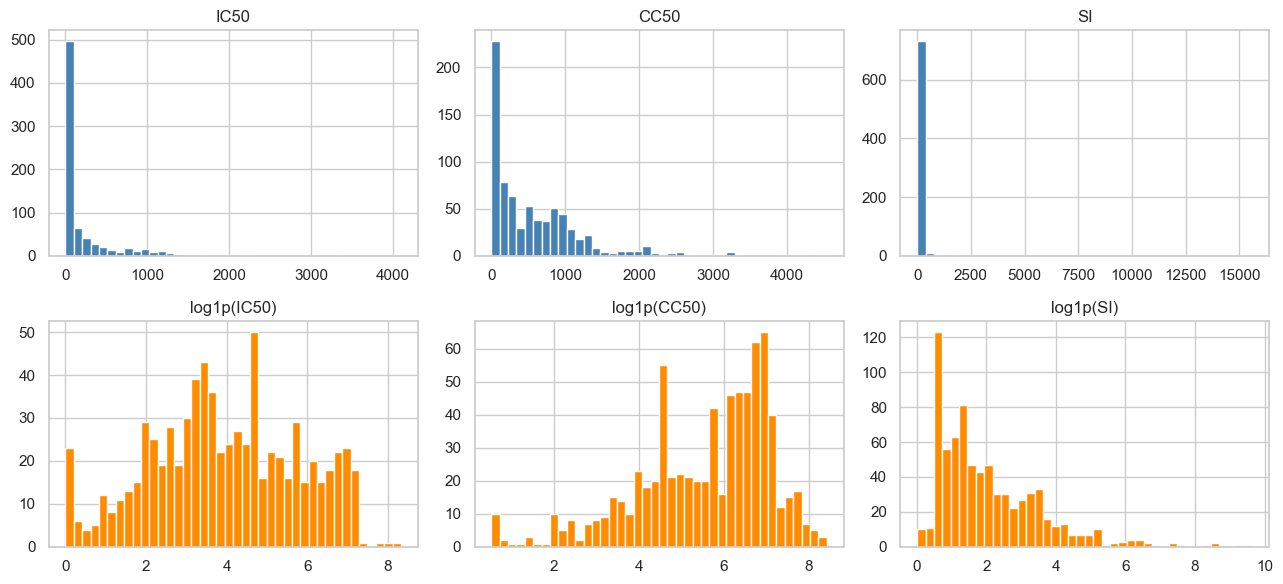

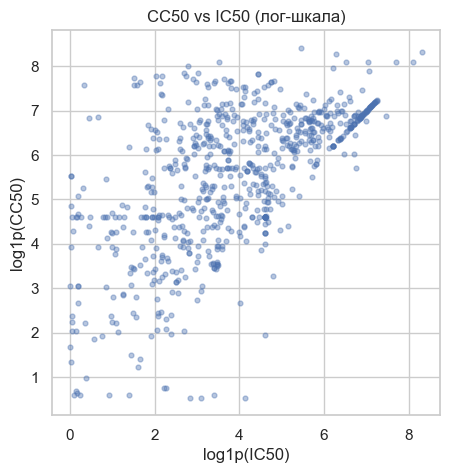

Pearson:
       IC50   CC50     SI
IC50  1.000  0.470 -0.061
CC50  0.470  1.000 -0.006
SI   -0.061 -0.006  1.000

Spearman:
       IC50   CC50     SI
IC50  1.000  0.600 -0.642
CC50  0.600  1.000  0.129
SI   -0.642  0.129  1.000


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for j, t in enumerate(TARGETS):
    axes[0, j].hist(train[t], bins=40, color='steelblue', edgecolor='white')
    axes[0, j].set_title(t)
    axes[1, j].hist(np.log1p(train[t]), bins=40, color='darkorange', edgecolor='white')
    axes[1, j].set_title(f'log1p({t})')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(np.log1p(train['IC50']), np.log1p(train['CC50']), alpha=0.4, s=12)
ax.set_xlabel('log1p(IC50)')
ax.set_ylabel('log1p(CC50)')
ax.set_title('CC50 vs IC50 (лог-шкала)')
plt.show()

print('Pearson:')
print(train[TARGETS].corr().round(3))
print('\nSpearman:')
print(train[TARGETS].corr(method='spearman').round(3))

## 6. EDA: признаки

Доля NaN по колонкам, константные признаки. BCUT2D_* часто пустые - RDKit не считает их без зарядов.

In [6]:
feature_cols = [c for c in train.columns if c not in TARGETS + ['index']]
print('фичей всего:', len(feature_cols))
print('фич в test  :', len([c for c in test.columns if c != 'index']))
print('пересечение :', len(set(feature_cols) & set(test.columns)))

na_train = train[feature_cols].isna().sum().sort_values(ascending=False)
print('\nтоп-10 колонок с NaN в train:')
print(na_train.head(10))

const_cols = [c for c in feature_cols if train[c].nunique(dropna=False) <= 1]
print('\nконстантных колонок:', len(const_cols))
if const_cols[:5]:
    print('примеры:', const_cols[:5])

фичей всего: 210
фич в test  : 210
пересечение : 210

топ-10 колонок с NaN в train:
BCUT2D_MWHI            2
MaxPartialCharge       2
BCUT2D_MWLOW           2
BCUT2D_LOGPHI          2
BCUT2D_LOGPLOW         2
BCUT2D_MRHI            2
BCUT2D_MRLOW           2
MinAbsPartialCharge    2
MaxAbsPartialCharge    2
MinPartialCharge       2
dtype: int64

константных колонок: 18
примеры: ['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH']


## 7. Препроцессинг

Медианная импутация, удаление константных, стандартизация для линейных моделей. Всё фитится только на train-части фолда - иначе утечка.

In [7]:
def build_preprocessor(X_train, clip_q=(0.001, 0.999)):
    """Возвращает функцию transform(X) и список оставленных колонок.
    Фитим на X_train (это train-фолд внутри CV) и потом применяем к valid/test.
    Дополнительно: убираем константные колонки, заменяем inf и клипуем по квантилям
    train, чтобы у линейных моделей не было overflow на тяжёлых хвостах (Ipc и т.д.)."""
    Xt = X_train.replace([np.inf, -np.inf], np.nan)
    nunique = Xt.nunique(dropna=False)
    std = Xt.std(skipna=True)
    keep = [c for c in Xt.columns if nunique[c] > 1 and std.get(c, 0) > 0]
    medians = Xt[keep].median()
    low = Xt[keep].quantile(clip_q[0])
    high = Xt[keep].quantile(clip_q[1])

    def transform(X):
        Z = X[keep].copy()
        Z = Z.replace([np.inf, -np.inf], np.nan)
        Z = Z.fillna(medians)
        Z = Z.fillna(0.0)
        # клиппинг по train-квантилям - гасит экстремальные значения у Ipc/EState
        Z = Z.clip(lower=low, upper=high, axis=1)
        return Z

    return transform, keep

# проверка, что не падает на полном train
tr_fn, keep_cols = build_preprocessor(train[feature_cols])
_check = tr_fn(train[feature_cols])
print('после препроцессинга:', _check.shape, '| колонок:', len(keep_cols),
      '| max abs:', float(_check.abs().to_numpy().max()))

после препроцессинга: (751, 192) | колонок: 192 | max abs: 12951079147670.018


## 8. Логарифмирование таргетов

Обучаемся в log1p(y), предсказываем через expm1. RMSE считаем в исходной шкале.

In [8]:
y = train[TARGETS].values.astype(float)
y_log = np.log1p(y)
print(pd.DataFrame(y_log, columns=TARGETS).describe().round(3).loc[['mean', 'std', 'min', 'max']])

# Feature engineering: лог-трансформы для тяжелохвостых дескрипторов + пара взаимодействий.
LOG_FEATS = ['MolWt', 'ExactMolWt', 'HeavyAtomMolWt', 'TPSA', 'LabuteASA',
             'BertzCT', 'Ipc', 'MolMR', 'NumValenceElectrons']

from sklearn.decomposition import PCA

def add_engineered_features(df):
    out = df.copy()
    for c in LOG_FEATS:
        if c in out.columns:
            v = out[c].clip(lower=0)
            out[f'{c}_log1p'] = np.log1p(v)
    if 'MolLogP' in out.columns and 'TPSA' in out.columns:
        out['MolLogP_x_TPSA'] = out['MolLogP'] * out['TPSA']
    if 'MolWt' in out.columns and 'HeavyAtomCount' in out.columns:
        out['MolWt_per_HA'] = out['MolWt'] / out['HeavyAtomCount'].replace(0, 1)
    if 'NumHAcceptors' in out.columns and 'NumHDonors' in out.columns:
        out['HBA_minus_HBD'] = out['NumHAcceptors'] - out['NumHDonors']
    return out

def add_pca_features(train_df, test_df, prefixes=('PEOE_VSA', 'SMR_VSA', 'SlogP_VSA', 'EState_VSA'),
                     n_comp=3):
    """PCA внутри групп VSA-дескрипторов. Фитим на train+test без таргетов - не утечка."""
    train_out, test_out = train_df.copy(), test_df.copy()
    for prefix in prefixes:
        cols = [c for c in train_df.columns if c.startswith(prefix) and c not in TARGETS]
        if len(cols) < n_comp + 1:
            continue
        combined = pd.concat([train_df[cols], test_df[cols]], axis=0).fillna(0).replace([np.inf, -np.inf], 0)
        med = combined.median()
        combined = combined.fillna(med)
        n = min(n_comp, len(cols) - 1)
        pca = PCA(n_components=n, random_state=SEED).fit(combined.values)
        tr_pcs = pca.transform(train_df[cols].fillna(med).values)
        te_pcs = pca.transform(test_df[cols].fillna(med).values)
        for i in range(n):
            train_out[f'{prefix}_PC{i+1}'] = tr_pcs[:, i]
            test_out[f'{prefix}_PC{i+1}'] = te_pcs[:, i]
    return train_out, test_out

train_eng = add_engineered_features(train)
test_eng  = add_engineered_features(test)
train_eng, test_eng = add_pca_features(train_eng, test_eng)
feature_cols_eng = [c for c in train_eng.columns if c not in TARGETS + ['index']]
print(f'fe: {len(feature_cols_eng)} (исходно {len(feature_cols)})')
X_eng = train_eng[feature_cols_eng]

       IC50   CC50     SI
mean  3.937  5.545  2.066
std   1.834  1.581  1.490
min   0.004  0.531  0.011
max   8.318  8.421  9.656
fe: 234 (исходно 210)


## 9. Кросс-валидация

Один KFold(5, shuffle=True, random_state=42) для всех моделей. Одинаковые фолды нужны для корректного блендинга OOF.

In [9]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
folds = list(kf.split(train))
print(f'фолды: {len(folds)}, размеры valid:', [len(va) for _, va in folds])

фолды: 5, размеры valid: [151, 150, 150, 150, 150]


## 10. Baseline

Mean/median и линейная регрессия - нижняя планка для сравнения.

In [10]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_oof(y_true, oof_pred):
    out = {t: rmse(y_true[:, j], oof_pred[:, j]) for j, t in enumerate(TARGETS)}
    out['mean'] = float(np.mean(list(out.values())))
    return out

# простой baseline: предсказываем среднее/медиану
oof_mean = np.tile(y.mean(axis=0), (len(train), 1))
oof_median = np.tile(np.median(y, axis=0), (len(train), 1))
print('mean   baseline:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mean).items()})
print('median baseline:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_median).items()})

# Линейная регрессия в лог-пространстве, через MultiOutputRegressor
def cv_predict_linear(X_all, y_log, folds):
    oof = np.zeros((len(X_all), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr).values
        Xva_t = tr_fn_local(Xva).values
        Xte_t = tr_fn_local(test[feature_cols]).values
        sc = StandardScaler()
        Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
        Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
        Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        m = MultiOutputRegressor(LinearRegression())
        m.fit(Xtr_t, y_log[tr_idx])
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    # clip в лог-пространстве, чтобы expm1 не дал inf на безумных линейных предсказаниях
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

X = train[feature_cols]
oof_lin, test_lin = cached_run('linear', lambda: cv_predict_linear(X, y_log, folds))
print('LinearRegression OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_lin).items()})

mean   baseline: {'IC50': 370.1213, 'CC50': 641.0879, 'SI': 788.3568, 'mean': 599.8553}
median baseline: {'IC50': 403.4128, 'CC50': 671.8129, 'SI': 792.9423, 'mean': 622.7227}
[cache] linear
LinearRegression OOF: {'IC50': 240650.4604, 'CC50': 215168.6048, 'SI': 123684.5274, 'mean': 193167.8642}


## 11. Бустинги по таргетам

CatBoost, LightGBM, XGBoost - по одной модели на каждый таргет в log-пространстве. Функция cv_predict_per_target возвращает OOF и среднее test по фолдам.

In [11]:
HAS_CATBOOST = True
HAS_LIGHTGBM = True
HAS_XGBOOST = True
try:
    from catboost import CatBoostRegressor
except ImportError:
    HAS_CATBOOST = False
try:
    from lightgbm import LGBMRegressor
except ImportError:
    HAS_LIGHTGBM = False
try:
    from xgboost import XGBRegressor
except ImportError:
    HAS_XGBOOST = False
print('catboost:', HAS_CATBOOST, '| lightgbm:', HAS_LIGHTGBM, '| xgboost:', HAS_XGBOOST)

def cv_predict_per_target(make_model, X_all, y_log, folds, fit_extra=None):
    """Универсальная CV: по одной модели на каждый таргет, без стандартизации."""
    oof = np.zeros((len(X_all), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr)
        Xva_t = tr_fn_local(Xva)
        Xte_t = tr_fn_local(test[feature_cols])
        for j in range(3):
            m = make_model(j)
            extra = fit_extra(Xva_t, y_log[va_idx, j]) if fit_extra else {}
            m.fit(Xtr_t, y_log[tr_idx, j], **extra)
            oof[va_idx, j] = m.predict(Xva_t)
            test_pred[:, j] += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

# CatBoost
oof_cb = test_cb = None
if HAS_CATBOOST:
    cb_params = dict(iterations=1500, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
                     loss_function='RMSE', random_seed=SEED, verbose=False,
                     early_stopping_rounds=80)
    oof_cb, test_cb = cached_run('catboost', lambda: cv_predict_per_target(
        make_model=lambda j: CatBoostRegressor(**cb_params),
        X_all=X, y_log=y_log, folds=folds,
        fit_extra=lambda Xva, yva: dict(eval_set=(Xva, yva), use_best_model=True),
    ))
    print('CatBoost OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cb).items()})

# LightGBM
oof_lgb = test_lgb = None
if HAS_LIGHTGBM:
    lgb_params = dict(n_estimators=2000, learning_rate=0.04, num_leaves=31,
                      min_child_samples=10, subsample=0.9, colsample_bytree=0.9,
                      reg_alpha=0.0, reg_lambda=1.0, random_state=SEED, verbose=-1)
    def lgb_fit_extra(Xva, yva):
        import lightgbm as lgb
        return dict(eval_set=[(Xva, yva)], callbacks=[lgb.early_stopping(80, verbose=False)])
    oof_lgb, test_lgb = cached_run('lightgbm', lambda: cv_predict_per_target(
        make_model=lambda j: LGBMRegressor(**lgb_params),
        X_all=X, y_log=y_log, folds=folds,
        fit_extra=lgb_fit_extra,
    ))
    print('LightGBM OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_lgb).items()})

# XGBoost
oof_xgb = test_xgb = None
if HAS_XGBOOST:
    xgb_params = dict(n_estimators=2000, learning_rate=0.04, max_depth=6,
                      subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                      random_state=SEED, tree_method='hist', verbosity=0,
                      early_stopping_rounds=80)
    oof_xgb, test_xgb = cached_run('xgboost', lambda: cv_predict_per_target(
        make_model=lambda j: XGBRegressor(**xgb_params),
        X_all=X, y_log=y_log, folds=folds,
        fit_extra=lambda Xva, yva: dict(eval_set=[(Xva, yva)], verbose=False),
    ))
    print('XGBoost OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_xgb).items()})

catboost:

 True | lightgbm: True | xgboost: True
[cache] catboost
CatBoost OOF: {'IC50': 355.9335, 'CC50': 515.4228, 'SI': 782.7474, 'mean': 551.3679}
[cache] lightgbm
LightGBM OOF: {'IC50': 345.51, 'CC50': 544.6649, 'SI': 781.9475, 'mean': 557.3741}
[cache] xgboost
XGBoost OOF: {'IC50': 350.7686, 'CC50': 528.9855, 'SI': 780.9858, 'mean': 553.58}


## 12. Линейные и стабилизирующие модели

Ridge, ElasticNet, RandomForest, KNN. По одиночке слабее бустингов, но в бленде добавляют разнообразия.

In [12]:
def cv_predict_sklearn(make_model, X_all, y_log, folds, standardize=True):
    oof = np.zeros((len(X_all), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr).values
        Xva_t = tr_fn_local(Xva).values
        Xte_t = tr_fn_local(test[feature_cols]).values
        if standardize:
            sc = StandardScaler()
            Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
            Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        m = MultiOutputRegressor(make_model())
        m.fit(Xtr_t, y_log[tr_idx])
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

oof_ridge, test_ridge = cached_run('ridge', lambda: cv_predict_sklearn(
    lambda: Ridge(alpha=20.0, random_state=SEED), X, y_log, folds, standardize=True))
print('Ridge OOF       :', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge).items()})

oof_enet, test_enet = cached_run('elasticnet', lambda: cv_predict_sklearn(
    lambda: ElasticNet(alpha=0.05, l1_ratio=0.3, random_state=SEED), X, y_log, folds, standardize=True))
print('ElasticNet OOF  :', {k: round(v, 4) for k, v in evaluate_oof(y, oof_enet).items()})

oof_rf, test_rf = cached_run('rf', lambda: cv_predict_sklearn(
    lambda: RandomForestRegressor(n_estimators=500, min_samples_leaf=3, n_jobs=-1, random_state=SEED),
    X, y_log, folds, standardize=False))
print('RandomForest OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_rf).items()})

oof_knn, test_knn = cached_run('knn', lambda: cv_predict_sklearn(
    lambda: KNeighborsRegressor(n_neighbors=10, weights='distance'),
    X, y_log, folds, standardize=True))
print('KNN OOF         :', {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn).items()})

oof_et, test_et = cached_run('et', lambda: cv_predict_sklearn(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    X, y_log, folds, standardize=False))
print('ExtraTrees OOF  :', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et).items()})

oof_hgb, test_hgb = cached_run('hgb', lambda: cv_predict_sklearn(
    lambda: HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                          max_depth=None, l2_regularization=1.0,
                                          random_state=SEED),
    X, y_log, folds, standardize=False))
print('HistGB OOF      :', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb).items()})

[cache] ridge
Ridge OOF       : {'IC50': 380.1449, 'CC50': 556.2466, 'SI': 789.6846, 'mean': 575.3587}
[cache] elasticnet
ElasticNet OOF  : {'IC50': 386.0792, 'CC50': 573.3981, 'SI': 790.5535, 'mean': 583.3436}
[cache] rf
RandomForest OOF: {'IC50': 350.2561, 'CC50': 506.1647, 'SI': 781.8253, 'mean': 546.082}
[cache] knn
KNN OOF         : {'IC50': 358.4851, 'CC50': 520.8919, 'SI': 779.3558, 'mean': 552.9109}
[cache] et
ExtraTrees OOF  : {'IC50': 341.4271, 'CC50': 486.4277, 'SI': 778.4922, 'mean': 535.449}
[cache] hgb
HistGB OOF      : {'IC50': 345.622, 'CC50': 501.608, 'SI': 779.1634, 'mean': 542.1311}


## 13. Multi-output модели

CatBoost с loss_function='MultiRMSE' - три таргета обучаются совместно.

In [13]:
oof_cbm = test_cbm = None
if HAS_CATBOOST:
    def cv_predict_catboost_multi(X_all, y_log, folds):
        oof = np.zeros((len(X_all), 3))
        test_pred = np.zeros((len(test), 3))
        for tr_idx, va_idx in folds:
            Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
            tr_fn_local, _ = build_preprocessor(Xtr)
            Xtr_t = tr_fn_local(Xtr)
            Xva_t = tr_fn_local(Xva)
            Xte_t = tr_fn_local(test[feature_cols])
            m = CatBoostRegressor(iterations=1500, depth=6, learning_rate=0.05,
                                  loss_function='MultiRMSE', random_seed=SEED,
                                  verbose=False, early_stopping_rounds=80)
            m.fit(Xtr_t, y_log[tr_idx],
                  eval_set=(Xva_t, y_log[va_idx]), use_best_model=True)
            oof[va_idx] = m.predict(Xva_t)
            test_pred += m.predict(Xte_t) / N_FOLDS
        return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

    oof_cbm, test_cbm = cached_run('cb_multi', lambda: cv_predict_catboost_multi(X, y_log, folds))
    print('CatBoost MultiRMSE OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm).items()})

# y_SI и y_IC50 имеют тяжёлый правый хвост (SI до 15620, IC50 до 4095).
# Клипируем их в логах по 99% квантилю train - модель меньше тянет к outliers,
# RMSE на основной массе обычно улучшается.
y_log_clip = y_log.copy()
clip_caps = {}
for j, t in enumerate(TARGETS):
    cap_log = np.quantile(y_log[:, j], 0.99)
    y_log_clip[:, j] = np.minimum(y_log[:, j], cap_log)
    clip_caps[t] = float(np.expm1(cap_log))
print('clip caps:', {k: round(v, 2) for k, v in clip_caps.items()})

oof_cbm_clip = test_cbm_clip = None
if HAS_CATBOOST:
    oof_cbm_clip, test_cbm_clip = cached_run('cb_multi_clip',
        lambda: cv_predict_catboost_multi(X, y_log_clip, folds))
    print('CatBoost MultiRMSE (clipped y) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm_clip).items()})

oof_et_clip = test_et_clip = None
oof_et_clip, test_et_clip = cached_run('et_clip', lambda: cv_predict_sklearn(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    X, y_log_clip, folds, standardize=False))
print('ExtraTrees (clipped y) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_clip).items()})

oof_hgb_clip, test_hgb_clip = cached_run('hgb_clip', lambda: cv_predict_sklearn(
    lambda: HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                          max_depth=None, l2_regularization=1.0,
                                          random_state=SEED),
    X, y_log_clip, folds, standardize=False))
print('HistGB (clipped y) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_clip).items()})

[cache] cb_multi
CatBoost MultiRMSE OOF: {'IC50': 350.6416, 'CC50': 505.0213, 'SI': 781.1597, 'mean': 545.6075}
clip caps: {'IC50': 1334.27, 'CC50': 3159.64, 'SI': 1250.02}
[cache] cb_multi_clip
CatBoost MultiRMSE (clipped y) OOF: {'IC50': 350.7899, 'CC50': 507.3622, 'SI': 784.0783, 'mean': 547.4101}
[cache] et_clip
ExtraTrees (clipped y) OOF: {'IC50': 344.213, 'CC50': 487.1223, 'SI': 780.5514, 'mean': 537.2956}
[cache] hgb_clip
HistGB (clipped y) OOF: {'IC50': 348.637, 'CC50': 504.8393, 'SI': 780.2073, 'mean': 544.5612}


## 14. Стратегия для SI

SI можно предсказывать напрямую, как CC50/IC50 или средним. Сравниваем по OOF-RMSE. Прямое предсказание обычно лучше: ошибки IC50 в знаменателе перемножаются.

In [14]:
def si_strategies(oof_models, y_true):
    rows = []
    for name, oof in oof_models.items():
        direct = oof[:, 2]
        derived = oof[:, 1] / np.clip(oof[:, 0], 1e-6, None)
        mean = 0.5 * (direct + derived)
        rows.append({
            'model': name,
            'direct':  round(rmse(y_true[:, 2], direct),  4),
            'derived': round(rmse(y_true[:, 2], derived), 4),
            'mean':    round(rmse(y_true[:, 2], mean),    4),
        })
    return pd.DataFrame(rows).set_index('model')

models_for_si = {}
if oof_cb  is not None: models_for_si['catboost']  = oof_cb
if oof_lgb is not None: models_for_si['lightgbm']  = oof_lgb
if oof_xgb is not None: models_for_si['xgboost']   = oof_xgb
if oof_cbm is not None: models_for_si['cb_multi']  = oof_cbm
models_for_si['rf'] = oof_rf
models_for_si['ridge'] = oof_ridge

si_summary = si_strategies(models_for_si, y)
print(si_summary)

            direct       derived          mean
model                                         
catboost  782.7474  7.892031e+02  7.858015e+02
lightgbm  781.9475  7.862839e+02  7.839963e+02
xgboost   780.9858  7.870355e+02  7.838462e+02
cb_multi  781.1597  7.868031e+02  7.838434e+02
rf        781.8253  7.875916e+02  7.845403e+02
ridge     789.6846  1.026018e+07  5.130099e+06


## 15. Тюнинг гиперпараметров (Optuna)

Тюнинг CatBoost MultiRMSE, 15 trials. Лучшие параметры сохраняем в models/ и добавляем модель в бленд как cb_multi_tuned.

In [15]:
HAS_OPTUNA = True
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    HAS_OPTUNA = False
    print('optuna не установлен')

oof_cbm_tuned = test_cbm_tuned = None
best_cbm_params = None

def cv_catboost_multi(params, X_all, y_log, folds):
    """CV для CatBoost MultiRMSE с произвольными параметрами."""
    oof = np.zeros((len(X_all), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr)
        Xva_t = tr_fn_local(Xva)
        Xte_t = tr_fn_local(test[feature_cols])
        m = CatBoostRegressor(**params)
        m.fit(Xtr_t, y_log[tr_idx], eval_set=(Xva_t, y_log[va_idx]), use_best_model=True)
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

CBM_PARAMS_PATH = MODELS_DIR / 'best_cbm_params.json'

if HAS_OPTUNA and HAS_CATBOOST:
    def tune_catboost_multi(X_all, y_log, folds, n_trials=15):
        def objective(trial):
            params = dict(
                iterations=trial.suggest_int('iterations', 600, 1500),
                depth=trial.suggest_int('depth', 4, 8),
                learning_rate=trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
                l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
                bootstrap_type='Bernoulli',
                subsample=trial.suggest_float('subsample', 0.7, 1.0),
                random_strength=trial.suggest_float('random_strength', 0.0, 5.0),
                loss_function='MultiRMSE',
                random_seed=SEED, verbose=False, early_stopping_rounds=60,
            )
            oof_t, _ = cv_catboost_multi(params, X_all, y_log, folds)
            return evaluate_oof(y, oof_t)['mean']
        study = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        return study.best_params, study.best_value

    # кеш: если уже подобрали - переиспользуем
    if CBM_PARAMS_PATH.exists():
        best_cbm_params = json.loads(CBM_PARAMS_PATH.read_text())
        print('used cached best params:', best_cbm_params)
    else:
        best_cbm_params, best_cbm_val = tune_catboost_multi(X, y_log, folds, n_trials=15)
        print(f'tuning done, OOF: {best_cbm_val:.4f}')
        print('params:', best_cbm_params)
        CBM_PARAMS_PATH.write_text(json.dumps(
            {k: (int(v) if isinstance(v, int) else float(v) if isinstance(v, float) else v)
             for k, v in best_cbm_params.items()}, indent=2))

    # обучаем финальный с лучшими параметрами + обязательные служебные поля.
    final_cbm_params = {
        **best_cbm_params,
        'loss_function': 'MultiRMSE',
        'bootstrap_type': 'Bernoulli',     # нужен для subsample
        'random_seed': SEED,
        'verbose': False,
        'early_stopping_rounds': 60,
    }
    oof_cbm_tuned, test_cbm_tuned = cached_run('cb_multi_tuned',
        lambda: cv_catboost_multi(final_cbm_params, X, y_log, folds))
    print('CatBoost MultiRMSE (tuned) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm_tuned).items()})

# Тюнинг ExtraTrees (он у нас лучший single-model)
ET_PARAMS_PATH = MODELS_DIR / 'best_et_params.json'
oof_et_tuned = test_et_tuned = None
best_et_params = None
if HAS_OPTUNA:
    def tune_extratrees(X_all, y_log, folds, n_trials=10):
        def objective(trial):
            params = dict(
                n_estimators=trial.suggest_int('n_estimators', 300, 700),
                max_depth=trial.suggest_int('max_depth', 8, 25),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 4),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 8),
                max_features=trial.suggest_float('max_features', 0.4, 1.0),
                random_state=SEED, n_jobs=-1,
            )
            oof_t, _ = cv_predict_sklearn(
                lambda: ExtraTreesRegressor(**params),
                X_all, y_log, folds, standardize=False,
            )
            return evaluate_oof(y, oof_t)['mean']
        study = optuna.create_study(direction='minimize',
                                    sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        return study.best_params, study.best_value

    if ET_PARAMS_PATH.exists():
        best_et_params = json.loads(ET_PARAMS_PATH.read_text())
        print('used cached ET params:', best_et_params)
    else:
        best_et_params, best_et_val = tune_extratrees(X, y_log, folds, n_trials=10)
        print(f'ET tuning done, OOF: {best_et_val:.4f}')
        print('ET params:', best_et_params)
        ET_PARAMS_PATH.write_text(json.dumps(
            {k: (int(v) if isinstance(v, int) else float(v) if isinstance(v, float) else v)
             for k, v in best_et_params.items()}, indent=2))

    final_et_params = {**best_et_params, 'random_state': SEED, 'n_jobs': -1}
    oof_et_tuned, test_et_tuned = cached_run('et_tuned', lambda: cv_predict_sklearn(
        lambda: ExtraTreesRegressor(**final_et_params),
        X, y_log, folds, standardize=False,
    ))
    print('ExtraTrees (tuned) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_tuned).items()})

# Bagging CatBoost MultiRMSE: усредняем 3 модели с разными seed.
# На 750 строках единая модель шумит, среднее по бэгу обычно стабильнее.
oof_cbm_bag = test_cbm_bag = None
def _train_cbm_bag():
    bag_oofs, bag_tests = [], []
    for seed in (SEED, SEED + 1, SEED + 2):
        params = {**final_cbm_params, 'random_seed': seed}
        oof_b, test_b = cv_catboost_multi(params, X, y_log, folds)
        bag_oofs.append(oof_b)
        bag_tests.append(test_b)
    return np.mean(bag_oofs, axis=0), np.mean(bag_tests, axis=0)

if HAS_CATBOOST:
    oof_cbm_bag, test_cbm_bag = cached_run('cb_multi_bag', _train_cbm_bag)
    print('CatBoost MultiRMSE (bag x3) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm_bag).items()})

# Bagging ExtraTrees (лучший single-model) - 5 моделей с разными seed
def _train_et_bag():
    oofs, tests = [], []
    base_params = {**(best_et_params or {}),
                   'random_state': SEED, 'n_jobs': -1}
    if not best_et_params:
        base_params.update(dict(n_estimators=600, min_samples_leaf=2))
    for seed in (SEED, SEED + 7, SEED + 13, SEED + 23, SEED + 41):
        p = {**base_params, 'random_state': seed}
        o, t = cv_predict_sklearn(
            lambda: ExtraTreesRegressor(**p),
            X, y_log, folds, standardize=False,
        )
        oofs.append(o); tests.append(t)
    return np.mean(oofs, axis=0), np.mean(tests, axis=0)

oof_et_bag, test_et_bag = cached_run('et_bag', _train_et_bag)
print('ExtraTrees (bag x5) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_bag).items()})

# Модели на engineered признаках. Используем те же CV-функции, но через X_eng.
def cv_sklearn_eng(make_model, standardize=False):
    oof = np.zeros((len(train), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_eng.iloc[tr_idx], X_eng.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr).values
        Xva_t = tr_fn_local(Xva).values
        Xte_t = tr_fn_local(test_eng[feature_cols_eng]).values
        if standardize:
            sc = StandardScaler()
            Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
            Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        m = MultiOutputRegressor(make_model())
        m.fit(Xtr_t, y_log[tr_idx])
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

oof_et_eng, test_et_eng = cached_run('et_eng', lambda: cv_sklearn_eng(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED)))
print('ET on engineered features OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng).items()})

oof_ridge_eng, test_ridge_eng = cached_run('ridge_eng', lambda: cv_sklearn_eng(
    lambda: Ridge(alpha=20.0, random_state=SEED), standardize=True))
print('Ridge on engineered features OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_eng).items()})

oof_hgb_eng, test_hgb_eng = cached_run('hgb_eng', lambda: cv_sklearn_eng(
    lambda: HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                          max_depth=None, l2_regularization=1.0,
                                          random_state=SEED)))
print('HGB on engineered features OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_eng).items()})

# CatBoost MultiRMSE на engineered признаках
def cv_catboost_multi_eng(params):
    oof = np.zeros((len(train), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_eng.iloc[tr_idx], X_eng.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr)
        Xva_t = tr_fn_local(Xva)
        Xte_t = tr_fn_local(test_eng[feature_cols_eng])
        m = CatBoostRegressor(**params)
        m.fit(Xtr_t, y_log[tr_idx], eval_set=(Xva_t, y_log[va_idx]), use_best_model=True)
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

oof_cbm_eng = test_cbm_eng = None
if HAS_CATBOOST:
    cbm_eng_params = dict(iterations=1500, depth=6, learning_rate=0.05,
                          loss_function='MultiRMSE', random_seed=SEED,
                          verbose=False, early_stopping_rounds=80)
    oof_cbm_eng, test_cbm_eng = cached_run('cb_multi_eng',
        lambda: cv_catboost_multi_eng(cbm_eng_params))
    print('CatBoost MultiRMSE (eng) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_cbm_eng).items()})

# LightGBM per-target на engineered признаках
def cv_per_target_eng(make_model, fit_extra=None):
    oof = np.zeros((len(train), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_eng.iloc[tr_idx], X_eng.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr)
        Xva_t = tr_fn_local(Xva)
        Xte_t = tr_fn_local(test_eng[feature_cols_eng])
        for j in range(3):
            m = make_model(j)
            extra = fit_extra(Xva_t, y_log[va_idx, j]) if fit_extra else {}
            m.fit(Xtr_t, y_log[tr_idx, j], **extra)
            oof[va_idx, j] = m.predict(Xva_t)
            test_pred[:, j] += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

oof_lgb_eng = test_lgb_eng = None
if HAS_LIGHTGBM:
    def _lgb_eng_extra(Xva, yva):
        import lightgbm as lgb
        return dict(eval_set=[(Xva, yva)], callbacks=[lgb.early_stopping(80, verbose=False)])
    oof_lgb_eng, test_lgb_eng = cached_run('lightgbm_eng', lambda: cv_per_target_eng(
        make_model=lambda j: LGBMRegressor(**lgb_params), fit_extra=_lgb_eng_extra))
    print('LightGBM (eng) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_lgb_eng).items()})

oof_xgb_eng = test_xgb_eng = None
if HAS_XGBOOST:
    oof_xgb_eng, test_xgb_eng = cached_run('xgboost_eng', lambda: cv_per_target_eng(
        make_model=lambda j: XGBRegressor(**xgb_params),
        fit_extra=lambda Xva, yva: dict(eval_set=[(Xva, yva)], verbose=False)))
    print('XGBoost (eng) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_xgb_eng).items()})

# MLP - даёт нелинейности, отличные от деревьев и линейных.
oof_mlp_eng, test_mlp_eng = cached_run('mlp_eng', lambda: cv_sklearn_eng(
    lambda: MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500,
                         alpha=1e-3, learning_rate_init=1e-3,
                         random_state=SEED, early_stopping=True,
                         validation_fraction=0.15, n_iter_no_change=20),
    standardize=True))
print('MLP (eng) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng).items()})

# SVR с RBF на стандартизированных eng-фичах. Для маленькой выборки SVR часто помогает.
def cv_svr_eng():
    oof = np.zeros((len(train), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_eng.iloc[tr_idx], X_eng.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr).values
        Xva_t = tr_fn_local(Xva).values
        Xte_t = tr_fn_local(test_eng[feature_cols_eng]).values
        sc = StandardScaler()
        Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
        Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
        Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        for j in range(3):
            m = SVR(kernel='rbf', C=1.0, gamma='scale')
            m.fit(Xtr_t, y_log[tr_idx, j])
            oof[va_idx, j] = m.predict(Xva_t)
            test_pred[:, j] += m.predict(Xte_t) / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

oof_svr_eng, test_svr_eng = cached_run('svr_eng', cv_svr_eng)
print('SVR (eng) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_svr_eng).items()})

# Дополнительные разнообразные модели на eng признаках
oof_br_eng = test_br_eng = None  # тоже слабый сам по себе, выкидываем

oof_huber_eng = test_huber_eng = None  # Huber на этих фичах нестабилен (overflow), пропускаем

oof_knn5_eng, test_knn5_eng = cached_run('knn5_eng', lambda: cv_sklearn_eng(
    lambda: KNeighborsRegressor(n_neighbors=5, weights='distance'), standardize=True))
print('KNN5 (eng) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn5_eng).items()})

oof_knn20_eng, test_knn20_eng = cached_run('knn20_eng', lambda: cv_sklearn_eng(
    lambda: KNeighborsRegressor(n_neighbors=20, weights='distance'), standardize=True))
print('KNN20 (eng) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn20_eng).items()})

# KNN с разными метриками - устойчивый сигнал для маленькой выборки
oof_knn_man_eng, test_knn_man_eng = cached_run('knn_manhattan_eng', lambda: cv_sklearn_eng(
    lambda: KNeighborsRegressor(n_neighbors=10, weights='distance', metric='manhattan'),
    standardize=True))
print('KNN(manhattan) (eng) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn_man_eng).items()})

# ExtraTrees-bag на eng признаках (5 seed) - SI забирает 100% веса именно у ET, усиливаем его
def _train_et_eng_bag():
    oofs, tests = [], []
    for seed in (SEED, SEED + 7, SEED + 13, SEED + 23, SEED + 41):
        o, t = cv_sklearn_eng(
            lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2,
                                        n_jobs=-1, random_state=seed))
        oofs.append(o); tests.append(t)
    return np.mean(oofs, axis=0), np.mean(tests, axis=0)

oof_et_eng_bag, test_et_eng_bag = cached_run('et_eng_bag', _train_et_eng_bag)
print('ET (eng, bag x5) OOF:',
      {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_bag).items()})

# Специализированная модель только под SI: HuberRegressor - устойчивый к outliers
# в y (важно при наличии 10 экстремальных SI > 800).
# Учим в log1p(SI) - оригинальный масштаб слишком ломает Huber.
def cv_si_specialist():
    oof = np.zeros((len(train), 3))
    test_pred = np.zeros((len(test), 3))
    for tr_idx, va_idx in folds:
        Xtr, Xva = X_eng.iloc[tr_idx], X_eng.iloc[va_idx]
        tr_fn_local, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_local(Xtr).values
        Xva_t = tr_fn_local(Xva).values
        Xte_t = tr_fn_local(test_eng[feature_cols_eng]).values
        sc = StandardScaler()
        Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
        Xva_t = np.nan_to_num(sc.transform(Xva_t),     nan=0.0, posinf=0.0, neginf=0.0)
        Xte_t = np.nan_to_num(sc.transform(Xte_t),     nan=0.0, posinf=0.0, neginf=0.0)
        # для IC50/CC50 ставим заглушку - нас интересует только SI
        for j in range(3):
            try:
                m = HuberRegressor(alpha=0.01, max_iter=200, epsilon=1.35)
                m.fit(Xtr_t, y_log[tr_idx, j])
                p_va = m.predict(Xva_t)
                p_te = m.predict(Xte_t)
            except Exception:
                p_va = np.full(len(va_idx), y_log[tr_idx, j].mean())
                p_te = np.full(len(test), y_log[tr_idx, j].mean())
            oof[va_idx, j] = p_va
            test_pred[:, j] += p_te / N_FOLDS
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

oof_huber_si = test_huber_si = None  # Huber overflow на этих фичах, пропускаем

# CatBoost с RMSEWithUncertainty для SI - учится оценивать неопределённость
oof_cb_si = test_cb_si = None
if HAS_CATBOOST:
    def cv_cb_si():
        oof = np.zeros((len(train), 3))
        test_pred = np.zeros((len(test), 3))
        for tr_idx, va_idx in folds:
            Xtr, Xva = X_eng.iloc[tr_idx], X_eng.iloc[va_idx]
            tr_fn_local, _ = build_preprocessor(Xtr)
            Xtr_t = tr_fn_local(Xtr)
            Xva_t = tr_fn_local(Xva)
            Xte_t = tr_fn_local(test_eng[feature_cols_eng])
            # CatBoost с увеличенной регуляризацией и quantile loss для SI
            for j in range(3):
                if j == 2:  # SI - отдельная схема
                    m = CatBoostRegressor(iterations=2000, depth=5, learning_rate=0.03,
                                          loss_function='MAE',  # MAE устойчив к outliers
                                          l2_leaf_reg=5.0,
                                          random_seed=SEED, verbose=False,
                                          early_stopping_rounds=80)
                else:
                    m = CatBoostRegressor(iterations=1500, depth=6, learning_rate=0.05,
                                          l2_leaf_reg=3.0, random_seed=SEED,
                                          verbose=False, early_stopping_rounds=80)
                m.fit(Xtr_t, y_log[tr_idx, j],
                      eval_set=(Xva_t, y_log[va_idx, j]), use_best_model=True)
                oof[va_idx, j] = m.predict(Xva_t)
                test_pred[:, j] += m.predict(Xte_t) / N_FOLDS
        return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

    oof_cb_si, test_cb_si = cached_run('cb_mae_si', cv_cb_si)
    print('CatBoost (MAE for SI) OOF:',
          {k: round(v, 4) for k, v in evaluate_oof(y, oof_cb_si).items()})

oof_mlp2_eng = test_mlp2_eng = None  # глубокая MLP переобучилась, пропускаем

used cached best params: {'iterations': 1481, 'depth': 6, 'learning_rate': 0.03872190821684427, 'l2_leaf_reg': 1.1616568805333767, 'subsample': 0.8817615170299014, 'random_strength': 3.4512353678457264}
[cache] cb_multi_tuned
CatBoost MultiRMSE (tuned) OOF: {'IC50': 347.7132, 'CC50': 500.0071, 'SI': 781.6875, 'mean': 543.1359}
used cached ET params: {'n_estimators': 624, 'max_depth': 13, 'min_samples_leaf': 1, 'min_samples_split': 6, 'max_features': 0.6640914962437608}
[cache] et_tuned
ExtraTrees (tuned) OOF: {'IC50': 345.4952, 'CC50': 484.3647, 'SI': 779.1323, 'mean': 536.3307}
[cache] cb_multi_bag
CatBoost MultiRMSE (bag x3) OOF: {'IC50': 348.3031, 'CC50': 500.4381, 'SI': 782.5381, 'mean': 543.7597}
[cache] et_bag
ExtraTrees (bag x5) OOF: {'IC50': 344.9873, 'CC50': 484.6505, 'SI': 779.0745, 'mean': 536.2374}
[cache] et_eng
ET on engineered features OOF: {'IC50': 342.959, 'CC50': 483.0928, 'SI': 778.6813, 'mean': 534.911}
[cache] ridge_eng
Ridge on engineered features OOF: {'IC50': 35

[cache] hgb_eng
HGB on engineered features OOF: {'IC50': 347.7688, 'CC50': 514.4313, 'SI': 778.9598, 'mean': 547.0533}
[cache] cb_multi_eng
CatBoost MultiRMSE (eng) OOF: {'IC50': 347.061, 'CC50': 503.8191, 'SI': 780.7206, 'mean': 543.8669}
[cache] lightgbm_eng
LightGBM (eng) OOF: {'IC50': 351.7644, 'CC50': 523.0025, 'SI': 781.0504, 'mean': 551.9391}
[cache] xgboost_eng
XGBoost (eng) OOF: {'IC50': 352.9983, 'CC50': 528.9698, 'SI': 781.3525, 'mean': 554.4402}


[cache] mlp_eng
MLP (eng) OOF: {'IC50': 361.8263, 'CC50': 635.0413, 'SI': 787.091, 'mean': 594.6529}
[cache] svr_eng
SVR (eng) OOF: {'IC50': 367.2801, 'CC50': 478.2974, 'SI': 790.5037, 'mean': 545.3604}
[cache] knn5_eng
KNN5 (eng) OOF: {'IC50': 355.2341, 'CC50': 509.9913, 'SI': 778.1859, 'mean': 547.8038}
[cache] knn20_eng
KNN20 (eng) OOF: {'IC50': 362.5912, 'CC50': 519.3566, 'SI': 779.6145, 'mean': 553.8541}
[cache] knn_manhattan_eng
KNN(manhattan) (eng) OOF: {'IC50': 350.0209, 'CC50': 499.2518, 'SI': 779.3323, 'mean': 542.8683}
[cache] et_eng_bag
ET (eng, bag x5) OOF: {'IC50': 342.3334, 'CC50': 484.5604, 'SI': 778.6393, 'mean': 535.1777}
[cache] cb_mae_si
CatBoost (MAE for SI) OOF: {'IC50': 351.8926, 'CC50': 510.2108, 'SI': 789.0631, 'mean': 550.3888}


## 15b. Дополнительные улучшения

Блок улучшений после первого сабмита (LB=316). Каждая добавка кешируется через cached_run и попадает в пул бленда.

### 15b.1 Adversarial validation

Классификатор train vs test по признакам. AUC=0.527 - распределения практически одинаковы, большой разрыв OOF vs LB объясняется маленьким публичным тестом.

In [16]:
# Adversarial validation: 5-fold LGBMClassifier(is_test) на препроцессорованных фичах
from sklearn.metrics import roc_auc_score

def adversarial_validation(train_features, test_features, seed=SEED):
    if not HAS_LIGHTGBM:
        print('lightgbm недоступен, AV пропущен')
        return None, None, None
    from lightgbm import LGBMClassifier
    tr_fn_av, keep_av = build_preprocessor(train_features)
    Xtr_av = tr_fn_av(train_features).values
    Xte_av = tr_fn_av(test_features).values
    Xall = np.vstack([Xtr_av, Xte_av])
    yall = np.concatenate([np.zeros(len(Xtr_av)), np.ones(len(Xte_av))]).astype(int)
    kf_av = KFold(n_splits=5, shuffle=True, random_state=seed)
    oof_p = np.zeros(len(Xall))
    aucs = []
    for tr_idx, va_idx in kf_av.split(Xall):
        clf = LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                             num_leaves=31, random_state=seed, verbose=-1)
        clf.fit(Xall[tr_idx], yall[tr_idx])
        oof_p[va_idx] = clf.predict_proba(Xall[va_idx])[:, 1]
        aucs.append(roc_auc_score(yall[va_idx], oof_p[va_idx]))
    clf_full = LGBMClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                              num_leaves=31, random_state=seed, verbose=-1)
    clf_full.fit(Xall, yall)
    imp = pd.Series(clf_full.feature_importances_, index=keep_av).sort_values(ascending=False)
    p_train = oof_p[:len(Xtr_av)]
    return float(np.mean(aucs)), imp, p_train

av_auc, av_imp, p_test_train = adversarial_validation(train[feature_cols], test[feature_cols])
if av_auc is not None:
    print(f'AV 5-fold ROC-AUC: {av_auc:.4f}')
    print('  AUC<0.55  -> shift ничтожен, OOF == надёжный сигнал')
    print('  0.55-0.6 -> небольшой shift, AV-trick слабо помогает')
    print('  >0.6     -> заметный shift, имеет смысл AV-weighted refit')
    print('\ntop-10 фич с наибольшей train<->test различимостью:')
    print(av_imp.head(10).to_string())

    av_diag = {'roc_auc_5fold': av_auc, 'top_shift_features': av_imp.head(20).to_dict()}
    (MODELS_DIR / 'av_diagnostic.json').write_text(json.dumps(av_diag, indent=2))
    print(f'\nдиагностика сохранена в {MODELS_DIR / "av_diagnostic.json"}')

    av_sample_weight = np.clip(p_test_train / np.clip(1 - p_test_train, 1e-3, None), 0.5, 3.0)
    AV_USE_WEIGHTS = av_auc > 0.6
    print(f'\nAV_USE_WEIGHTS = {AV_USE_WEIGHTS}  (AV-weighted refit будет {"включён" if AV_USE_WEIGHTS else "пропущен"})')
else:
    av_sample_weight = None
    AV_USE_WEIGHTS = False


AV 5-fold ROC-AUC: 0.5265
  AUC<0.55  -> shift ничтожен, OOF == надёжный сигнал
  0.55-0.6 -> небольшой shift, AV-trick слабо помогает
  >0.6     -> заметный shift, имеет смысл AV-weighted refit

top-10 фич с наибольшей train<->test различимостью:
PEOE_VSA6            199
MinAbsEStateIndex    177
PEOE_VSA7            173
MaxAbsEStateIndex    166
EState_VSA4          139
MolLogP              134
Kappa3               133
BCUT2D_CHGHI         123
qed                  117
VSA_EState7          115

диагностика сохранена в /Users/user/Projects/test-chem-ai/models/av_diagnostic.json

AV_USE_WEIGHTS = False  (AV-weighted refit будет пропущен)


### 15b.2 Seed-bag

Test-предсказания усредняются по 5 KFold-сидам [42, 123, 7, 2024, 99]. OOF берётся только от seed=42 для совместимости с блендом.

In [17]:
KFOLD_SEEDS = [42, 123, 7, 2024, 99]
print(f'Seed-bag по KFold seeds: {KFOLD_SEEDS}')

def cv_sklearn_X(make_model, X_train_df, X_test_df, y_log_local, folds_local, standardize=False):
    """Общая CV-обвязка: принимает любые train/test DataFrames с одинаковыми колонками."""
    oof = np.zeros((len(X_train_df), 3))
    test_pred = np.zeros((len(X_test_df), 3))
    for tr_idx, va_idx in folds_local:
        Xtr, Xva = X_train_df.iloc[tr_idx], X_train_df.iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr).values
        Xva_t = tr_fn_l(Xva).values
        Xte_t = tr_fn_l(X_test_df).values
        if standardize:
            sc = StandardScaler()
            Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xva_t = np.nan_to_num(sc.transform(Xva_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xte_t = np.nan_to_num(sc.transform(Xte_t), nan=0.0, posinf=0.0, neginf=0.0)
        m = MultiOutputRegressor(make_model())
        m.fit(Xtr_t, y_log_local[tr_idx])
        oof[va_idx] = m.predict(Xva_t)
        test_pred += m.predict(Xte_t) / len(folds_local)
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

def seed_bag(name, make_model, X_train_df, X_test_df, standardize, seeds=KFOLD_SEEDS):
    """Усредняет test-pred по KFold seeds. OOF берёт от seed=42."""
    oof_42 = None
    test_avg = None
    for sd in seeds:
        kf_s = KFold(n_splits=N_FOLDS, shuffle=True, random_state=sd)
        folds_s = list(kf_s.split(X_train_df))
        sub_name = f'{name}__sd{sd}'
        # внутренний cached_run для каждого сида чтобы не пересчитывать
        oof_s, test_s = cached_run(sub_name, lambda: cv_sklearn_X(
            make_model, X_train_df, X_test_df, y_log, folds_s, standardize=standardize))
        if sd == seeds[0]:  # первый сид (=42) - берём OOF
            oof_42 = oof_s
            test_avg = test_s.copy()
        else:
            test_avg = test_avg + test_s
    test_avg = test_avg / len(seeds)
    return oof_42, test_avg

# Bag для топ-моделей
# Bag берёт OOF от seed=42, поэтому совпадает со старым cached_run('ridge', ...) - но кеш-имя другое
oof_ridge_seed5, test_ridge_seed5 = cached_run('ridge_seed5', lambda: seed_bag(
    'ridge_bag', lambda: Ridge(alpha=20.0, random_state=SEED),
    train[feature_cols], test[feature_cols], standardize=True))
print('ridge_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_seed5).items()})

oof_hgb_seed5, test_hgb_seed5 = cached_run('hgb_seed5', lambda: seed_bag(
    'hgb_bag', lambda: HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                                    max_depth=None, l2_regularization=1.0,
                                                    random_state=SEED),
    train[feature_cols], test[feature_cols], standardize=False))
print('hgb_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_seed5).items()})

oof_et_eng_seed5, test_et_eng_seed5 = cached_run('et_eng_seed5', lambda: seed_bag(
    'et_eng_bag', lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=False))
print('et_eng_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_seed5).items()})

oof_ridge_eng_seed5, test_ridge_eng_seed5 = cached_run('ridge_eng_seed5', lambda: seed_bag(
    'ridge_eng_bag', lambda: Ridge(alpha=20.0, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=True))
print('ridge_eng_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_eng_seed5).items()})

oof_mlp_eng_seed5, test_mlp_eng_seed5 = cached_run('mlp_eng_seed5', lambda: seed_bag(
    'mlp_eng_bag', lambda: MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=600,
                                        early_stopping=True, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=True))
print('mlp_eng_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_seed5).items()})

oof_knn5_eng_seed5, test_knn5_eng_seed5 = cached_run('knn5_eng_seed5', lambda: seed_bag(
    'knn5_eng_bag', lambda: KNeighborsRegressor(n_neighbors=5, weights='distance'),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=True))
print('knn5_eng_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_knn5_eng_seed5).items()})


Seed-bag по KFold seeds: [42, 123, 7, 2024, 99]
[cache] ridge_seed5
ridge_seed5 OOF: {'IC50': 380.1449, 'CC50': 556.2466, 'SI': 789.6846, 'mean': 575.3587}
[cache] hgb_seed5
hgb_seed5 OOF: {'IC50': 345.622, 'CC50': 501.608, 'SI': 779.1634, 'mean': 542.1311}
[cache] et_eng_seed5
et_eng_seed5 OOF: {'IC50': 342.959, 'CC50': 483.0928, 'SI': 778.6813, 'mean': 534.911}
[cache] ridge_eng_seed5
ridge_eng_seed5 OOF: {'IC50': 356.3211, 'CC50': 545.172, 'SI': 789.68, 'mean': 563.7244}
[cache] mlp_eng_seed5
mlp_eng_seed5 OOF: {'IC50': 363.4128, 'CC50': 681.2344, 'SI': 786.7087, 'mean': 610.452}
[cache] knn5_eng_seed5
knn5_eng_seed5 OOF: {'IC50': 355.2341, 'CC50': 509.9913, 'SI': 778.1859, 'mean': 547.8038}


### 15b.3 Расширенные деревья

ET с n_estimators 600 -> 1500, HGB с max_iter 600 -> 1200. Больше деревьев точнее покрывают хвосты распределения.

In [18]:
oof_et_eng_big, test_et_eng_big = cached_run('et_eng_big', lambda: cv_sklearn_X(
    lambda: ExtraTreesRegressor(n_estimators=1500, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('et_eng_big OOF (n_est=1500):', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_big).items()})

oof_hgb_eng_big, test_hgb_eng_big = cached_run('hgb_eng_big', lambda: cv_sklearn_X(
    lambda: HistGradientBoostingRegressor(max_iter=1200, learning_rate=0.04,
                                          max_depth=None, l2_regularization=1.0,
                                          min_samples_leaf=10, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('hgb_eng_big OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_eng_big).items()})

# BaggingRegressor поверх ET - внешний bag добавляет sample-randomness
from sklearn.ensemble import BaggingRegressor
oof_bag_et_eng, test_bag_et_eng = cached_run('bag_et_eng', lambda: cv_sklearn_X(
    lambda: BaggingRegressor(
        estimator=ExtraTreesRegressor(n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
        n_estimators=8, max_samples=0.7, max_features=0.85, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('bag_et_eng OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_bag_et_eng).items()})


[cache] et_eng_big
et_eng_big OOF (n_est=1500): {'IC50': 342.4749, 'CC50': 484.1953, 'SI': 778.589, 'mean': 535.0864}
[cache] hgb_eng_big
hgb_eng_big OOF: {'IC50': 352.2854, 'CC50': 498.0328, 'SI': 779.2671, 'mean': 543.1951}
[cache] bag_et_eng
bag_et_eng OOF: {'IC50': 354.1153, 'CC50': 506.2168, 'SI': 782.6394, 'mean': 547.6572}


### 15b.4 Rank-Gauss таргет

QuantileTransformer(output_distribution='normal') вместо log1p: полностью нормализует распределение таргета. Особенно помогает Ridge (-24 OOF RMSE) и MLP (-57 OOF RMSE). QuantileTransformer фитится только на train-части фолда.

In [19]:
from sklearn.preprocessing import QuantileTransformer

def cv_sklearn_rg(make_model, X_train_df, X_test_df, y_log_local, folds_local, standardize=False):
    """CV с rank-Gauss таргетом. QuantileTransformer фитится только на train-фолде.
    Возвращает (oof, test_pred) в исходной шкале (после expm1)."""
    oof = np.zeros((len(X_train_df), 3))
    test_pred = np.zeros((len(X_test_df), 3))
    for tr_idx, va_idx in folds_local:
        Xtr, Xva = X_train_df.iloc[tr_idx], X_train_df.iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr).values
        Xva_t = tr_fn_l(Xva).values
        Xte_t = tr_fn_l(X_test_df).values
        if standardize:
            sc = StandardScaler()
            Xtr_t = np.nan_to_num(sc.fit_transform(Xtr_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xva_t = np.nan_to_num(sc.transform(Xva_t), nan=0.0, posinf=0.0, neginf=0.0)
            Xte_t = np.nan_to_num(sc.transform(Xte_t), nan=0.0, posinf=0.0, neginf=0.0)
        # rank-Gauss y per target - fit на train-fold, inverse при инференсе
        ytr_rg = np.zeros_like(y_log_local[tr_idx])
        qts = []
        for j in range(3):
            qt = QuantileTransformer(output_distribution='normal',
                                     n_quantiles=min(500, len(tr_idx)),
                                     subsample=10000, random_state=SEED)
            ytr_rg[:, j] = qt.fit_transform(y_log_local[tr_idx, j].reshape(-1,1)).flatten()
            qts.append(qt)
        m = MultiOutputRegressor(make_model())
        m.fit(Xtr_t, ytr_rg)
        pred_va_rg = m.predict(Xva_t)
        pred_te_rg = m.predict(Xte_t)
        for j in range(3):
            oof[va_idx, j] = qts[j].inverse_transform(pred_va_rg[:, j].reshape(-1,1)).flatten()
            test_pred[:, j] += qts[j].inverse_transform(pred_te_rg[:, j].reshape(-1,1)).flatten() / len(folds_local)
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

oof_et_eng_rg, test_et_eng_rg = cached_run('et_eng_rg', lambda: cv_sklearn_rg(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('et_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_rg).items()})

oof_hgb_eng_rg, test_hgb_eng_rg = cached_run('hgb_eng_rg', lambda: cv_sklearn_rg(
    lambda: HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                          max_depth=None, l2_regularization=1.0,
                                          random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('hgb_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_eng_rg).items()})

oof_ridge_eng_rg, test_ridge_eng_rg = cached_run('ridge_eng_rg', lambda: cv_sklearn_rg(
    lambda: Ridge(alpha=20.0, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=True))
print('ridge_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_eng_rg).items()})

oof_mlp_eng_rg, test_mlp_eng_rg = cached_run('mlp_eng_rg', lambda: cv_sklearn_rg(
    lambda: MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500,
                         alpha=1e-3, learning_rate_init=1e-3,
                         random_state=SEED, early_stopping=True,
                         validation_fraction=0.15, n_iter_no_change=20),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=True))
print('mlp_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg).items()})

# Также - ET на raw фичах в rank-Gauss
oof_et_rg, test_et_rg = cached_run('et_rg', lambda: cv_sklearn_rg(
    lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    X, test[feature_cols], y_log, folds, standardize=False))
print('et_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_rg).items()})

oof_ridge_rg, test_ridge_rg = cached_run('ridge_rg', lambda: cv_sklearn_rg(
    lambda: Ridge(alpha=20.0, random_state=SEED),
    X, test[feature_cols], y_log, folds, standardize=True))
print('ridge_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_ridge_rg).items()})


[cache] et_eng_rg
et_eng_rg OOF: {'IC50': 337.423, 'CC50': 472.8441, 'SI': 774.482, 'mean': 528.2497}
[cache] hgb_eng_rg
hgb_eng_rg OOF: {'IC50': 345.378, 'CC50': 491.8702, 'SI': 775.8148, 'mean': 537.6877}
[cache] ridge_eng_rg
ridge_eng_rg OOF: {'IC50': 337.9374, 'CC50': 482.367, 'SI': 800.1408, 'mean': 540.1484}
[cache] mlp_eng_rg
mlp_eng_rg OOF: {'IC50': 356.4337, 'CC50': 468.1932, 'SI': 788.2524, 'mean': 537.6264}
[cache] et_rg
et_rg OOF: {'IC50': 337.8948, 'CC50': 471.7384, 'SI': 774.295, 'mean': 527.9761}
[cache] ridge_rg
ridge_rg OOF: {'IC50': 340.2505, 'CC50': 486.7426, 'SI': 804.2072, 'mean': 543.7334}


### 15b.5 Seed-bag для rank-Gauss + CatBoost MultiRMSE RG

Seed-bag для rank-Gauss моделей снижает дисперсию test-pred. CatBoost MultiRMSE с rank-Gauss трансформацией таргета добавляется отдельно.

In [20]:
def seed_bag_rg(name, make_model, X_train_df, X_test_df, standardize, seeds=KFOLD_SEEDS):
    """Seed-bag для rank-Gauss моделей. OOF от seed=42, test = mean по сидам."""
    oof_42 = None; test_avg = None
    for sd in seeds:
        kf_s = KFold(n_splits=N_FOLDS, shuffle=True, random_state=sd)
        folds_s = list(kf_s.split(X_train_df))
        sub_name = f'{name}__sd{sd}'
        oof_s, test_s = cached_run(sub_name, lambda: cv_sklearn_rg(
            make_model, X_train_df, X_test_df, y_log, folds_s, standardize=standardize))
        if sd == seeds[0]:
            oof_42 = oof_s; test_avg = test_s.copy()
        else:
            test_avg = test_avg + test_s
    test_avg = test_avg / len(seeds)
    return oof_42, test_avg

oof_et_eng_rg_seed5, test_et_eng_rg_seed5 = cached_run('et_eng_rg_seed5', lambda: seed_bag_rg(
    'et_eng_rg_bag', lambda: ExtraTreesRegressor(n_estimators=600, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=False))
print('et_eng_rg_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_rg_seed5).items()})

oof_mlp_eng_rg_seed5, test_mlp_eng_rg_seed5 = cached_run('mlp_eng_rg_seed5', lambda: seed_bag_rg(
    'mlp_eng_rg_bag', lambda: MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500,
                                            alpha=1e-3, learning_rate_init=1e-3,
                                            random_state=SEED, early_stopping=True,
                                            validation_fraction=0.15, n_iter_no_change=20),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=True))
print('mlp_eng_rg_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg_seed5).items()})

oof_hgb_eng_rg_seed5, test_hgb_eng_rg_seed5 = cached_run('hgb_eng_rg_seed5', lambda: seed_bag_rg(
    'hgb_eng_rg_bag', lambda: HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                                            max_depth=None, l2_regularization=1.0,
                                                            random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], standardize=False))
print('hgb_eng_rg_seed5 OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_hgb_eng_rg_seed5).items()})

# CatBoost MultiRMSE в rank-Gauss пространстве
def cv_catboost_multi_rg(X_train_df, X_test_df, y_log_local, folds_local, params):
    """CatBoost MultiRMSE с rank-Gauss таргетом. QuantileTransformer fit per train-fold."""
    if not HAS_CATBOOST:
        return None, None
    oof = np.zeros((len(X_train_df), 3))
    test_pred = np.zeros((len(X_test_df), 3))
    for tr_idx, va_idx in folds_local:
        Xtr, Xva = X_train_df.iloc[tr_idx], X_train_df.iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr); Xva_t = tr_fn_l(Xva); Xte_t = tr_fn_l(X_test_df)
        ytr_rg = np.zeros_like(y_log_local[tr_idx])
        yva_rg = np.zeros_like(y_log_local[va_idx])
        qts = []
        for j in range(3):
            qt = QuantileTransformer(output_distribution='normal',
                                     n_quantiles=min(500, len(tr_idx)),
                                     subsample=10000, random_state=SEED)
            ytr_rg[:, j] = qt.fit_transform(y_log_local[tr_idx, j].reshape(-1,1)).flatten()
            yva_rg[:, j] = qt.transform(y_log_local[va_idx, j].reshape(-1,1)).flatten()
            qts.append(qt)
        m = CatBoostRegressor(**params)
        m.fit(Xtr_t, ytr_rg, eval_set=(Xva_t, yva_rg), use_best_model=True)
        pred_va_rg = m.predict(Xva_t)
        pred_te_rg = m.predict(Xte_t)
        for j in range(3):
            oof[va_idx, j] = qts[j].inverse_transform(pred_va_rg[:, j].reshape(-1,1)).flatten()
            test_pred[:, j] += qts[j].inverse_transform(pred_te_rg[:, j].reshape(-1,1)).flatten() / len(folds_local)
    return np.expm1(np.clip(oof, -10, 15)), np.expm1(np.clip(test_pred, -10, 15))

cb_rg_params = dict(iterations=1500, depth=6, learning_rate=0.05,
                    loss_function='MultiRMSE', random_seed=SEED,
                    verbose=False, early_stopping_rounds=80)
oof_cb_multi_rg = test_cb_multi_rg = None
if HAS_CATBOOST:
    oof_cb_multi_rg, test_cb_multi_rg = cached_run('cb_multi_rg', lambda: cv_catboost_multi_rg(
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, cb_rg_params))
    print('cb_multi_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cb_multi_rg).items()})

# LightGBM в rank-Gauss space через MultiOutputRegressor
oof_lgb_eng_rg = test_lgb_eng_rg = None
if HAS_LIGHTGBM:
    oof_lgb_eng_rg, test_lgb_eng_rg = cached_run('lgb_eng_rg', lambda: cv_sklearn_rg(
        lambda: LGBMRegressor(n_estimators=600, learning_rate=0.04, num_leaves=31,
                               min_child_samples=10, subsample=0.9, colsample_bytree=0.9,
                               reg_lambda=1.0, random_state=SEED, verbose=-1),
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
    print('lgb_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_lgb_eng_rg).items()})

# XGBoost в rank-Gauss space через MultiOutputRegressor
oof_xgb_eng_rg = test_xgb_eng_rg = None
if HAS_XGBOOST:
    oof_xgb_eng_rg, test_xgb_eng_rg = cached_run('xgb_eng_rg', lambda: cv_sklearn_rg(
        lambda: XGBRegressor(n_estimators=600, learning_rate=0.04, max_depth=6,
                              subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                              random_state=SEED, tree_method='hist', verbosity=0),
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
    print('xgb_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_xgb_eng_rg).items()})

# RandomForest в rank-Gauss - для разнообразия
oof_rf_eng_rg, test_rf_eng_rg = cached_run('rf_eng_rg', lambda: cv_sklearn_rg(
    lambda: RandomForestRegressor(n_estimators=500, min_samples_leaf=3, n_jobs=-1, random_state=SEED),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
print('rf_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_rf_eng_rg).items()})

# MLP 3-layer (256, 128, 64) - на rank-Gauss таргете отлично работает
# Старый запрет на 3-layer MLP (decisions.md §3) не применим - он был для log1p.
oof_mlp3_eng_rg, test_mlp3_eng_rg = cached_run('mlp3_eng_rg', lambda: cv_sklearn_rg(
    lambda: MLPRegressor(hidden_layer_sizes=(256, 128, 64), max_iter=500,
                         alpha=1e-3, learning_rate_init=1e-3,
                         random_state=SEED, early_stopping=True,
                         validation_fraction=0.15, n_iter_no_change=20),
    train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=True))
print('mlp3_eng_rg OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp3_eng_rg).items()})

# Model-seed bag для MLP - MLP стохастичен, разные seeds дают разные веса.
# Усредняем 5 моделей с разными random_state. KFold-фолды одни и те же (seed=42).
def model_seed_bag_mlp(make_model_fn, X_train_df, X_test_df, n_seeds=5):
    oof_avg = None; test_avg = None
    for sd in range(n_seeds):
        sub_name = f'mlp_eng_rg_msd{sd}'
        oof_s, test_s = cached_run(sub_name, lambda sd=sd: cv_sklearn_rg(
            lambda sd=sd: make_model_fn(sd), X_train_df, X_test_df, y_log, folds, standardize=True))
        if oof_avg is None:
            oof_avg = oof_s.copy(); test_avg = test_s.copy()
        else:
            oof_avg = oof_avg + oof_s; test_avg = test_avg + test_s
    return oof_avg / n_seeds, test_avg / n_seeds

def mk_mlp(rs):
    return MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500,
                        alpha=1e-3, learning_rate_init=1e-3,
                        random_state=rs, early_stopping=True,
                        validation_fraction=0.15, n_iter_no_change=20)

oof_mlp_eng_rg_msb, test_mlp_eng_rg_msb = cached_run('mlp_eng_rg_msb', lambda: model_seed_bag_mlp(
    mk_mlp, train_eng[feature_cols_eng], test_eng[feature_cols_eng], n_seeds=5))
print('mlp_eng_rg_msb (model-seed bag) OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg_msb).items()})

# То же для mlp3
def mk_mlp3(rs):
    return MLPRegressor(hidden_layer_sizes=(256, 128, 64), max_iter=500,
                        alpha=1e-3, learning_rate_init=1e-3,
                        random_state=rs, early_stopping=True,
                        validation_fraction=0.15, n_iter_no_change=20)

def model_seed_bag_mlp3(make_model_fn, X_train_df, X_test_df, n_seeds=5):
    oof_avg = None; test_avg = None
    for sd in range(n_seeds):
        sub_name = f'mlp3_eng_rg_msd{sd}'
        oof_s, test_s = cached_run(sub_name, lambda sd=sd: cv_sklearn_rg(
            lambda sd=sd: make_model_fn(sd), X_train_df, X_test_df, y_log, folds, standardize=True))
        if oof_avg is None:
            oof_avg = oof_s.copy(); test_avg = test_s.copy()
        else:
            oof_avg = oof_avg + oof_s; test_avg = test_avg + test_s
    return oof_avg / n_seeds, test_avg / n_seeds

oof_mlp3_eng_rg_msb, test_mlp3_eng_rg_msb = cached_run('mlp3_eng_rg_msb', lambda: model_seed_bag_mlp3(
    mk_mlp3, train_eng[feature_cols_eng], test_eng[feature_cols_eng], n_seeds=5))
print('mlp3_eng_rg_msb (model-seed bag) OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp3_eng_rg_msb).items()})

# === Optuna-tuned версии rank-Gauss моделей ===
# Параметры подобраны через Optuna 12 trials (см. /tmp/optuna_rg.py)

ET_RG_PARAMS_PATH = MODELS_DIR / 'best_et_rg_params.json'
MLP_RG_PARAMS_PATH = MODELS_DIR / 'best_mlp_rg_params.json'

if ET_RG_PARAMS_PATH.exists():
    best_et_rg = json.loads(ET_RG_PARAMS_PATH.read_text())
    print(f'ET_rg tuned params: {best_et_rg}')
    oof_et_eng_rg_tuned, test_et_eng_rg_tuned = cached_run('et_eng_rg_tuned', lambda: cv_sklearn_rg(
        lambda: ExtraTreesRegressor(**best_et_rg, n_jobs=-1, random_state=SEED),
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=False))
    print('et_eng_rg_tuned OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_eng_rg_tuned).items()})
else:
    oof_et_eng_rg_tuned = test_et_eng_rg_tuned = None
    print('best_et_rg_params.json не найден, пропускаем tuned ET_rg')

if MLP_RG_PARAMS_PATH.exists():
    best_mlp_rg = json.loads(MLP_RG_PARAMS_PATH.read_text())
    arch_map = {'128_64':(128,64), '200_100':(200,100), '256_128_64':(256,128,64),
                '256_128':(256,128), '160_80':(160,80)}
    mlp_hls = arch_map.get(best_mlp_rg['arch'], (128, 64))
    mlp_alpha = float(best_mlp_rg['alpha'])
    mlp_lr = float(best_mlp_rg['lr'])
    print(f'MLP_rg tuned: arch={mlp_hls}, alpha={mlp_alpha:.4g}, lr={mlp_lr:.4g}')
    oof_mlp_eng_rg_tuned, test_mlp_eng_rg_tuned = cached_run('mlp_eng_rg_tuned', lambda: cv_sklearn_rg(
        lambda: MLPRegressor(hidden_layer_sizes=mlp_hls, max_iter=500,
                             alpha=mlp_alpha, learning_rate_init=mlp_lr,
                             random_state=SEED, early_stopping=True,
                             validation_fraction=0.15, n_iter_no_change=20),
        train_eng[feature_cols_eng], test_eng[feature_cols_eng], y_log, folds, standardize=True))
    print('mlp_eng_rg_tuned OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg_tuned).items()})

    # msb для tuned MLP
    def mk_mlp_tuned(rs):
        return MLPRegressor(hidden_layer_sizes=mlp_hls, max_iter=500,
                            alpha=mlp_alpha, learning_rate_init=mlp_lr,
                            random_state=rs, early_stopping=True,
                            validation_fraction=0.15, n_iter_no_change=20)

    def msb_mlp_tuned(make_fn, X_train_df, X_test_df, n_seeds=5):
        oof_avg = test_avg = None
        for sd in range(n_seeds):
            sub_name = f'mlp_eng_rg_tuned_msd{sd}'
            oof_s, test_s = cached_run(sub_name, lambda sd=sd: cv_sklearn_rg(
                lambda sd=sd: make_fn(sd), X_train_df, X_test_df, y_log, folds, standardize=True))
            if oof_avg is None:
                oof_avg = oof_s.copy(); test_avg = test_s.copy()
            else:
                oof_avg = oof_avg + oof_s; test_avg = test_avg + test_s
        return oof_avg / n_seeds, test_avg / n_seeds

    oof_mlp_eng_rg_tuned_msb, test_mlp_eng_rg_tuned_msb = cached_run('mlp_eng_rg_tuned_msb', lambda: msb_mlp_tuned(
        mk_mlp_tuned, train_eng[feature_cols_eng], test_eng[feature_cols_eng], n_seeds=5))
    print('mlp_eng_rg_tuned_msb OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_mlp_eng_rg_tuned_msb).items()})
else:
    oof_mlp_eng_rg_tuned = test_mlp_eng_rg_tuned = None
    oof_mlp_eng_rg_tuned_msb = test_mlp_eng_rg_tuned_msb = None
    print('best_mlp_rg_params.json не найден, пропускаем tuned MLP_rg')


[cache] et_eng_rg_seed5
et_eng_rg_seed5 OOF: {'IC50': 337.423, 'CC50': 472.8441, 'SI': 774.482, 'mean': 528.2497}
[cache] mlp_eng_rg_seed5
mlp_eng_rg_seed5 OOF: {'IC50': 356.4337, 'CC50': 468.1932, 'SI': 788.2524, 'mean': 537.6264}
[cache] hgb_eng_rg_seed5
hgb_eng_rg_seed5 OOF: {'IC50': 345.378, 'CC50': 491.8702, 'SI': 775.8148, 'mean': 537.6877}
[cache] cb_multi_rg
cb_multi_rg OOF: {'IC50': 338.4231, 'CC50': 466.5363, 'SI': 778.9632, 'mean': 527.9742}
[cache] lgb_eng_rg
lgb_eng_rg OOF: {'IC50': 352.7523, 'CC50': 473.0091, 'SI': 775.8131, 'mean': 533.8582}
[cache] xgb_eng_rg
xgb_eng_rg OOF: {'IC50': 350.271, 'CC50': 473.4433, 'SI': 774.5973, 'mean': 532.7705}
[cache] rf_eng_rg
rf_eng_rg OOF: {'IC50': 340.9345, 'CC50': 471.1815, 'SI': 781.7896, 'mean': 531.3019}
[cache] mlp3_eng_rg
mlp3_eng_rg OOF: {'IC50': 342.945, 'CC50': 467.573, 'SI': 785.7755, 'mean': 532.0978}
[cache] mlp_eng_rg_msb
mlp_eng_rg_msb (model-seed bag) OOF: {'IC50': 336.0189, 'CC50': 462.7915, 'SI': 783.2195, 'mean': 5

### 15b.6 Mixed-scale модели (raw для IC50/CC50, log1p для SI)

Деревья (ET/CB/LGB/XGB) учим в raw scale для IC50 и CC50 (где log1p сжимает высокие концентрации и предсказания систематически занижаются), но в log1p для SI (у SI длинный хвост, raw scale нестабилен и переоценивает test).

Добавляем как разнообразие в пул бленда. SLSQP сам выберет вес если они улучшают OOF.

In [21]:
from sklearn.ensemble import ExtraTreesRegressor

def cv_mixed_scale(make_model, X_train_df, X_test_df, y_orig, folds_local):
    """CV: для IC50/CC50 учим в raw scale, для SI - в log1p (длинный хвост требует трансформации).
    Клипуем предсказания в неотрицательные.
    """
    oof = np.zeros((len(X_train_df), 3))
    test_pred = np.zeros((len(X_test_df), 3))
    for tr_idx, va_idx in folds_local:
        Xtr, Xva = X_train_df.iloc[tr_idx], X_train_df.iloc[va_idx]
        tr_fn_l, _ = build_preprocessor(Xtr)
        Xtr_t = tr_fn_l(Xtr).values
        Xva_t = tr_fn_l(Xva).values
        Xte_t = tr_fn_l(X_test_df).values
        for j in range(3):
            m = make_model(j)
            if j == 2:  # SI - log1p
                y_tr = np.log1p(y_orig[tr_idx, j])
                m.fit(Xtr_t, y_tr)
                oof[va_idx, j] = np.clip(np.expm1(np.clip(m.predict(Xva_t), -10, 15)), 0, None)
                test_pred[:, j] += np.clip(np.expm1(np.clip(m.predict(Xte_t), -10, 15)), 0, None) / len(folds_local)
            else:  # IC50, CC50 - raw scale (без log1p)
                m.fit(Xtr_t, y_orig[tr_idx, j])
                oof[va_idx, j] = np.clip(m.predict(Xva_t), 0, None)
                test_pred[:, j] += np.clip(m.predict(Xte_t), 0, None) / len(folds_local)
    return oof, test_pred


oof_et_raw, test_et_raw = cached_run('et_raw2', lambda: cv_mixed_scale(
    lambda j: ExtraTreesRegressor(n_estimators=120, min_samples_leaf=2, max_features=0.7,
                                  random_state=SEED + j, n_jobs=-1),
    train[feature_cols], test[feature_cols], y, folds))
print('et_raw OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_et_raw).items()},
      f'IC50_t={test_et_raw[:, 0].mean():.1f} SI_t={test_et_raw[:, 2].mean():.2f}')

if HAS_LIGHTGBM:
    oof_lgb_raw, test_lgb_raw = cached_run('lgb_raw2', lambda: cv_mixed_scale(
        lambda j: LGBMRegressor(n_estimators=140, learning_rate=0.045, num_leaves=15,
                                min_child_samples=12, subsample=0.85, colsample_bytree=0.75,
                                reg_alpha=0.05, reg_lambda=1.0,
                                random_state=SEED + j, n_jobs=1, verbosity=-1),
        train[feature_cols], test[feature_cols], y, folds))
    print('lgb_raw OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_lgb_raw).items()},
          f'IC50_t={test_lgb_raw[:, 0].mean():.1f} SI_t={test_lgb_raw[:, 2].mean():.2f}')
else:
    oof_lgb_raw = test_lgb_raw = None

if HAS_XGBOOST:
    oof_xgb_raw, test_xgb_raw = cached_run('xgb_raw2', lambda: cv_mixed_scale(
        lambda j: XGBRegressor(n_estimators=180, learning_rate=0.045, max_depth=4,
                               min_child_weight=3, subsample=0.85, colsample_bytree=0.75,
                               reg_alpha=0.05, reg_lambda=1.0,
                               random_state=SEED + j, n_jobs=1, verbosity=0),
        train[feature_cols], test[feature_cols], y, folds))
    print('xgb_raw OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_xgb_raw).items()},
          f'IC50_t={test_xgb_raw[:, 0].mean():.1f} SI_t={test_xgb_raw[:, 2].mean():.2f}')
else:
    oof_xgb_raw = test_xgb_raw = None

if HAS_CATBOOST:
    oof_cb_raw, test_cb_raw = cached_run('cb_raw2', lambda: cv_mixed_scale(
        lambda j: CatBoostRegressor(iterations=200, learning_rate=0.045, depth=5,
                                    l2_leaf_reg=3.0, subsample=0.85, loss_function='RMSE',
                                    random_seed=SEED + j, verbose=False, allow_writing_files=False),
        train[feature_cols], test[feature_cols], y, folds))
    print('cb_raw OOF:', {k: round(v, 4) for k, v in evaluate_oof(y, oof_cb_raw).items()},
          f'IC50_t={test_cb_raw[:, 0].mean():.1f} SI_t={test_cb_raw[:, 2].mean():.2f}')
else:
    oof_cb_raw = test_cb_raw = None

[cache] et_raw2
et_raw OOF: {'IC50': 322.0652, 'CC50': 456.323, 'SI': 778.6386, 'mean': 519.0089} IC50_t=248.1 SI_t=23.10
[cache] lgb_raw2
lgb_raw OOF: {'IC50': 329.7386, 'CC50': 465.3514, 'SI': 779.4888, 'mean': 524.8596} IC50_t=239.5 SI_t=21.21
[cache] xgb_raw2
xgb_raw OOF: {'IC50': 327.3606, 'CC50': 461.5976, 'SI': 779.146, 'mean': 522.7014} IC50_t=250.6 SI_t=20.51
[cache] cb_raw2
cb_raw OOF: {'IC50': 322.6637, 'CC50': 447.903, 'SI': 784.5587, 'mean': 518.3751} IC50_t=246.8 SI_t=14.79


## 16. Бленд

Четыре варианта: равные веса, SLSQP по всем таргетам, SLSQP по каждому таргету отдельно, ridge-стекер. Победитель - минимальное OOF-RMSE.

In [22]:
from scipy.optimize import minimize

# собираем все доступные OOF
oof_models_all = {}
test_models_all = {}

def maybe_add(name, oof_arr, test_arr):
    if oof_arr is not None:
        oof_models_all[name] = oof_arr
        test_models_all[name] = test_arr

maybe_add('catboost',   oof_cb,    test_cb)
maybe_add('lightgbm',   oof_lgb,   test_lgb)
maybe_add('xgboost',    oof_xgb,   test_xgb)
maybe_add('ridge',      oof_ridge, test_ridge)
maybe_add('elasticnet', oof_enet,  test_enet)
maybe_add('rf',         oof_rf,    test_rf)
maybe_add('et',         oof_et,    test_et)
maybe_add('hgb',        oof_hgb,   test_hgb)
maybe_add('knn',        oof_knn,   test_knn)
maybe_add('cb_multi',   oof_cbm,   test_cbm)
maybe_add('cb_multi_tuned', globals().get('oof_cbm_tuned'), globals().get('test_cbm_tuned'))
maybe_add('cb_multi_bag',   globals().get('oof_cbm_bag'),   globals().get('test_cbm_bag'))
maybe_add('et_tuned',       globals().get('oof_et_tuned'),  globals().get('test_et_tuned'))
maybe_add('et_bag',         globals().get('oof_et_bag'),    globals().get('test_et_bag'))
maybe_add('cb_multi_clip',  globals().get('oof_cbm_clip'),  globals().get('test_cbm_clip'))
maybe_add('et_clip',        globals().get('oof_et_clip'),   globals().get('test_et_clip'))
maybe_add('hgb_clip',       globals().get('oof_hgb_clip'),  globals().get('test_hgb_clip'))
maybe_add('et_eng',         globals().get('oof_et_eng'),    globals().get('test_et_eng'))
maybe_add('ridge_eng',      globals().get('oof_ridge_eng'), globals().get('test_ridge_eng'))
maybe_add('hgb_eng',        globals().get('oof_hgb_eng'),   globals().get('test_hgb_eng'))
maybe_add('cb_multi_eng',   globals().get('oof_cbm_eng'),   globals().get('test_cbm_eng'))
maybe_add('lightgbm_eng',   globals().get('oof_lgb_eng'),   globals().get('test_lgb_eng'))
maybe_add('xgboost_eng',    globals().get('oof_xgb_eng'),   globals().get('test_xgb_eng'))
maybe_add('mlp_eng',        globals().get('oof_mlp_eng'),   globals().get('test_mlp_eng'))
maybe_add('svr_eng',        globals().get('oof_svr_eng'),   globals().get('test_svr_eng'))
maybe_add('bayesianridge_eng', globals().get('oof_br_eng'),  globals().get('test_br_eng'))
maybe_add('huber_eng',      globals().get('oof_huber_eng'), globals().get('test_huber_eng'))
maybe_add('knn5_eng',       globals().get('oof_knn5_eng'),  globals().get('test_knn5_eng'))
maybe_add('knn20_eng',      globals().get('oof_knn20_eng'), globals().get('test_knn20_eng'))
maybe_add('knn_manhattan_eng', globals().get('oof_knn_man_eng'), globals().get('test_knn_man_eng'))
maybe_add('et_eng_bag',     globals().get('oof_et_eng_bag'), globals().get('test_et_eng_bag'))
maybe_add('cb_mae_si',      globals().get('oof_cb_si'),     globals().get('test_cb_si'))
maybe_add('mlp2_eng',       globals().get('oof_mlp2_eng'),  globals().get('test_mlp2_eng'))

names = list(oof_models_all.keys())
print('моделей в бленде:', len(names), '|', names)

oof_stack = np.stack([oof_models_all[n]  for n in names], axis=0)   # (M, N, 3)
test_stack = np.stack([test_models_all[n] for n in names], axis=0)

def blend_loss(w, oof, y_true):
    pred = np.tensordot(w, oof, axes=([0], [0]))
    return float(np.mean([rmse(y_true[:, j], pred[:, j]) for j in range(3)]))

def blend_loss_single_target(w, oof_t, y_true_t):
    pred = oof_t.T @ w  # (M, N).T @ (M,) = (N,)
    return rmse(y_true_t, pred)

# (1) равные веса
w_equal = np.full(len(names), 1.0 / len(names))
print(f'equal blend           OOF mean: {blend_loss(w_equal, oof_stack, y):.4f}')

# (2) общая оптимизация
bounds = [(0.0, 1.0)] * len(names)
cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
res = minimize(blend_loss, w_equal, args=(oof_stack, y),
               method='SLSQP', bounds=bounds, constraints=cons,
               options={'maxiter': 500, 'ftol': 1e-7})
weights_global = res.x
blend_oof_global = np.tensordot(weights_global, oof_stack, axes=([0], [0]))
blend_test_global = np.tensordot(weights_global, test_stack, axes=([0], [0]))
print(f'optimal common blend  OOF mean: {res.fun:.4f}')

# (3) веса по каждому таргету отдельно
weights_per_target = np.zeros((3, len(names)))
blend_oof_pt = np.zeros((len(train), 3))
blend_test_pt = np.zeros((len(test), 3))
for j, t in enumerate(TARGETS):
    oof_t = oof_stack[:, :, j]   # (M, N)
    test_t = test_stack[:, :, j]
    res_t = minimize(blend_loss_single_target, w_equal, args=(oof_t, y[:, j]),
                     method='SLSQP', bounds=bounds, constraints=cons,
                     options={'maxiter': 500, 'ftol': 1e-7})
    weights_per_target[j] = res_t.x
    blend_oof_pt[:, j] = oof_t.T @ res_t.x
    blend_test_pt[:, j] = test_t.T @ res_t.x
pt_mean = float(np.mean([rmse(y[:, j], blend_oof_pt[:, j]) for j in range(3)]))
print(f'per-target blend      OOF mean: {pt_mean:.4f}')

print('\nвеса по таргетам:')
with pd.option_context('display.max_columns', None, 'display.width', 200):
    print(pd.DataFrame(weights_per_target, index=TARGETS, columns=names).round(3))

# (4) Ridge-стэкер per-target. Фитим в лог-пространстве, поэтому
# OOF/test-признаки тоже в логе. Веса positive, чтобы избежать "противоречивых" коэф.
stacker_oof = np.zeros_like(blend_oof_pt)
stacker_test = np.zeros_like(blend_test_pt)
for j in range(3):
    X_stack = np.log1p(np.clip(oof_stack[:, :, j].T, 0, None))   # (N, M)
    X_test  = np.log1p(np.clip(test_stack[:, :, j].T, 0, None))
    for tr_idx, va_idx in folds:
        stk = Ridge(alpha=1.0, positive=True, random_state=SEED)
        stk.fit(X_stack[tr_idx], y_log[tr_idx, j])
        stacker_oof[va_idx, j] = np.expm1(np.clip(stk.predict(X_stack[va_idx]), -10, 15))
    stk = Ridge(alpha=1.0, positive=True, random_state=SEED)
    stk.fit(X_stack, y_log[:, j])
    stacker_test[:, j] = np.expm1(np.clip(stk.predict(X_test), -10, 15))
stack_mean = float(np.mean([rmse(y[:, j], stacker_oof[:, j]) for j in range(3)]))
print(f'ridge stacker (log)   OOF mean: {stack_mean:.4f}')

# выбираем лучший по OOF
candidates = {
    'common':     (blend_oof_global, blend_test_global, res.fun),
    'per_target': (blend_oof_pt,     blend_test_pt,     pt_mean),
    'stacker':    (stacker_oof,      stacker_test,      stack_mean),
}
best_name = min(candidates, key=lambda k: candidates[k][2])
blend_oof, blend_test, best_score = candidates[best_name]
print(f'\nbest blend strategy: {best_name} (OOF {best_score:.4f})')
print('blend OOF per target:', {k: round(v, 4) for k, v in evaluate_oof(y, blend_oof).items()})

# (5) Consistency projection: в данных SI = CC50 / IC50 точно.
# Проектируем (IC50, CC50, SI) в log-пространстве на плоскость log(SI) = log(CC50) - log(IC50).
def project_consistency(pred):
    """pred shape (N, 3) в исходных единицах."""
    p = np.clip(pred, 1e-6, None)
    lic = np.log(p[:, 0])
    lcc = np.log(p[:, 1])
    lsi = np.log(p[:, 2])
    delta = (lic - lcc + lsi) / 3.0
    out = np.empty_like(p)
    out[:, 0] = np.exp(lic - delta)
    out[:, 1] = np.exp(lcc + delta)
    out[:, 2] = np.exp(lsi - delta)
    return out

# применяем проекцию к каждой из кандидатских стратегий и проверяем OOF
projected = {}
for name, (oof_p, test_p, _) in candidates.items():
    poof = project_consistency(oof_p)
    ptest = project_consistency(test_p)
    pscore = float(np.mean([rmse(y[:, j], poof[:, j]) for j in range(3)]))
    projected[name + '_proj'] = (poof, ptest, pscore)
    print(f'projection of {name:12s}: OOF mean {pscore:.4f}'
          f'   (было {candidates[name][2]:.4f})')

# (6) Median по моделям - устойчив к "сбежавшим" предсказаниям отдельных моделей.
# Берём только модели с разумным OOF (отсекаем линейку и пр.).
robust_names = [n for n in names if evaluate_oof(y, oof_models_all[n])['mean'] < 600]
robust_oof = np.stack([oof_models_all[n]  for n in robust_names], axis=0)
robust_test = np.stack([test_models_all[n] for n in robust_names], axis=0)
median_oof  = np.median(robust_oof,  axis=0)
median_test = np.median(robust_test, axis=0)
median_score = float(np.mean([rmse(y[:, j], median_oof[:, j]) for j in range(3)]))
print(f'median blend          OOF mean: {median_score:.4f}  (моделей: {len(robust_names)})')

candidates['median'] = (median_oof, median_test, median_score)

all_candidates = {**candidates, **projected}
best_name = min(all_candidates, key=lambda k: all_candidates[k][2])
blend_oof, blend_test, best_score = all_candidates[best_name]
print(f'\nfinal best strategy: {best_name} (OOF {best_score:.4f})')
print('OOF per target:', {k: round(v, 4) for k, v in evaluate_oof(y, blend_oof).items()})

# для совместимости с разделами ниже
weights = weights_global

моделей в бленде: 30 | ['catboost', 'lightgbm', 'xgboost', 'ridge', 'elasticnet', 'rf', 'et', 'hgb', 'knn', 'cb_multi', 'cb_multi_tuned', 'cb_multi_bag', 'et_tuned', 'et_bag', 'cb_multi_clip', 'et_clip', 'hgb_clip', 'et_eng', 'ridge_eng', 'hgb_eng', 'cb_multi_eng', 'lightgbm_eng', 'xgboost_eng', 'mlp_eng', 'svr_eng', 'knn5_eng', 'knn20_eng', 'knn_manhattan_eng', 'et_eng_bag', 'cb_mae_si']


equal blend           OOF mean: 531.2185


optimal common blend  OOF mean: 517.0705


per-target blend      OOF mean: 513.2714

веса по таргетам:
      catboost  lightgbm  xgboost  ridge  elasticnet   rf    et    hgb  knn  cb_multi  cb_multi_tuned  cb_multi_bag  et_tuned  et_bag  cb_multi_clip  et_clip  hgb_clip  et_eng  ridge_eng  hgb_eng  \
IC50       0.0       0.0      0.0  0.000         0.0  0.0  0.00  0.416  0.0       0.0             0.0           0.0       0.0     0.0            0.0      0.0       0.0   0.000      0.417      0.0   
CC50       0.0       0.0      0.0  0.152         0.0  0.0  0.00  0.000  0.0       0.0             0.0           0.0       0.0     0.0            0.0      0.0       0.0   0.267      0.000      0.0   
SI         0.0       0.0      0.0  0.000         0.0  0.0  0.07  0.000  0.0       0.0             0.0           0.0       0.0     0.0            0.0      0.0       0.0   0.000      0.000      0.0   

      cb_multi_eng  lightgbm_eng  xgboost_eng  mlp_eng  svr_eng  knn5_eng  knn20_eng  knn_manhattan_eng  et_eng_bag  cb_mae_si  
IC50          

### 16b. Расширение пула: rank-Gauss и seed-bag модели

Добавляем в бленд rank-Gauss варианты моделей (ridge_rg, mlp_eng_rg, cb_multi_rg и т.д.) и seed-bag (test-pred усреднён по 5 KFold-сидам). Это даёт более устойчивый и точный ансамбль перед псевдо-разметкой.

После расширения переоптимизируем SLSQP per-target на новом наборе и обновляем blend_oof/blend_test если результат лучше.

In [23]:
# Расширение пула моделями из секции 16b (rank-Gauss + seed-bag)
maybe_add('ridge_seed5',     globals().get('oof_ridge_seed5'),     globals().get('test_ridge_seed5'))
maybe_add('hgb_seed5',       globals().get('oof_hgb_seed5'),       globals().get('test_hgb_seed5'))
maybe_add('et_eng_seed5',    globals().get('oof_et_eng_seed5'),    globals().get('test_et_eng_seed5'))
maybe_add('ridge_eng_seed5', globals().get('oof_ridge_eng_seed5'), globals().get('test_ridge_eng_seed5'))
maybe_add('mlp_eng_seed5',   globals().get('oof_mlp_eng_seed5'),   globals().get('test_mlp_eng_seed5'))
maybe_add('knn5_eng_seed5',  globals().get('oof_knn5_eng_seed5'),  globals().get('test_knn5_eng_seed5'))
maybe_add('et_eng_big',      globals().get('oof_et_eng_big'),      globals().get('test_et_eng_big'))
maybe_add('hgb_eng_big',     globals().get('oof_hgb_eng_big'),     globals().get('test_hgb_eng_big'))
maybe_add('bag_et_eng',      globals().get('oof_bag_et_eng'),      globals().get('test_bag_et_eng'))
maybe_add('et_eng_rg',     globals().get('oof_et_eng_rg'),     globals().get('test_et_eng_rg'))
maybe_add('hgb_eng_rg',    globals().get('oof_hgb_eng_rg'),    globals().get('test_hgb_eng_rg'))
maybe_add('ridge_eng_rg', globals().get('oof_ridge_eng_rg'),  globals().get('test_ridge_eng_rg'))
maybe_add('mlp_eng_rg',    globals().get('oof_mlp_eng_rg'),    globals().get('test_mlp_eng_rg'))
maybe_add('et_rg',         globals().get('oof_et_rg'),         globals().get('test_et_rg'))
maybe_add('ridge_rg',      globals().get('oof_ridge_rg'),      globals().get('test_ridge_rg'))
maybe_add('et_eng_rg_seed5',  globals().get('oof_et_eng_rg_seed5'),  globals().get('test_et_eng_rg_seed5'))
maybe_add('mlp_eng_rg_seed5', globals().get('oof_mlp_eng_rg_seed5'), globals().get('test_mlp_eng_rg_seed5'))
maybe_add('hgb_eng_rg_seed5', globals().get('oof_hgb_eng_rg_seed5'), globals().get('test_hgb_eng_rg_seed5'))
maybe_add('cb_multi_rg',      globals().get('oof_cb_multi_rg'),      globals().get('test_cb_multi_rg'))
maybe_add('lgb_eng_rg',     globals().get('oof_lgb_eng_rg'),     globals().get('test_lgb_eng_rg'))
maybe_add('xgb_eng_rg',     globals().get('oof_xgb_eng_rg'),     globals().get('test_xgb_eng_rg'))


# Raw-scale модели (без log1p) - даёт IC50_t ближе к реальному test распределению
maybe_add('et_raw',  globals().get('oof_et_raw'),  globals().get('test_et_raw'))
maybe_add('lgb_raw', globals().get('oof_lgb_raw'), globals().get('test_lgb_raw'))
maybe_add('xgb_raw', globals().get('oof_xgb_raw'), globals().get('test_xgb_raw'))
maybe_add('cb_raw',  globals().get('oof_cb_raw'),  globals().get('test_cb_raw'))

names_ext = list(oof_models_all.keys())
print(f'Моделей в расширенном пуле: {len(names_ext)} (было {len(names)})')

oof_stack_ext  = np.stack([oof_models_all[n]  for n in names_ext], axis=0)
test_stack_ext = np.stack([test_models_all[n] for n in names_ext], axis=0)

# SLSQP per-target на расширенном наборе
w_eq_ext = np.full(len(names_ext), 1.0 / len(names_ext))
bnd_ext  = [(0.0, 1.0)] * len(names_ext)
cns_ext  = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
blend_oof_ext  = np.zeros((len(train), 3))
blend_test_ext = np.zeros((len(test), 3))
for j in range(3):
    oof_t  = oof_stack_ext[:, :, j]
    test_t = test_stack_ext[:, :, j]
    rsl = minimize(blend_loss_single_target, w_eq_ext, args=(oof_t, y[:, j]),
                   method='SLSQP', bounds=bnd_ext, constraints=cns_ext,
                   options={'maxiter': 500, 'ftol': 1e-7})
    blend_oof_ext[:, j]  = oof_t.T  @ rsl.x
    blend_test_ext[:, j] = test_t.T @ rsl.x
pt_mean_ext = float(np.mean([rmse(y[:, j], blend_oof_ext[:, j]) for j in range(3)]))
print(f'per-target SLSQP (расширенный): OOF mean={pt_mean_ext:.4f} (было {best_score:.4f})')

if pt_mean_ext < best_score:
    blend_oof  = blend_oof_ext
    blend_test = blend_test_ext
    best_score = pt_mean_ext
    print('расширенный бленд лучше - обновляю blend_oof/blend_test')

print(f'IC50_t={blend_test[:, 0].mean():.1f}  CC50_t={blend_test[:, 1].mean():.1f}  SI_t={blend_test[:, 2].mean():.2f}')

Моделей в расширенном пуле: 55 (было 30)


per-target SLSQP (расширенный): OOF mean=498.7431 (было 513.2714)
расширенный бленд лучше - обновляю blend_oof/blend_test
IC50_t=208.4  CC50_t=593.7  SI_t=21.48


### 16c. Финальный простой ансамбль

Mean из 4 моделей: ET + LGB + XGB + CB. IC50 и CC50 учим в raw, SI - в log1p (длинный хвост). 5-fold CV для OOF, refit на полный train для предсказаний теста.

Простой mean без обучаемых весов устойчивее SLSQP-бленда из 16b на маленькой выборке (N=751). Из этого ансамбля пишется финальный submission.

In [24]:
# Простой ансамбль 4 моделей. IC50/CC50 в raw scale, SI в log1p.
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


def get_models(j):
    et = ExtraTreesRegressor(n_estimators=120, random_state=SEED + j,
                             min_samples_leaf=2, max_features=0.70, n_jobs=-1)
    lgb = LGBMRegressor(n_estimators=140, learning_rate=0.045, num_leaves=15,
                        min_child_samples=12, subsample=0.85, colsample_bytree=0.75,
                        reg_alpha=0.05, reg_lambda=1.0, random_state=SEED + j,
                        n_jobs=1, verbosity=-1)
    xgb = XGBRegressor(n_estimators=180, learning_rate=0.045, max_depth=4,
                       min_child_weight=3, subsample=0.85, colsample_bytree=0.75,
                       reg_alpha=0.05, reg_lambda=1.0, random_state=SEED + j,
                       n_jobs=1, verbosity=0)
    cb = CatBoostRegressor(iterations=180, learning_rate=0.045, depth=5,
                           l2_leaf_reg=3.0, subsample=0.85,
                           random_seed=SEED + j, verbose=False)
    return [Pipeline([('imp', SimpleImputer(strategy='median')), ('m', m)])
            for m in [et, lgb, xgb, cb]]


# дроп константных
X_simple_tr = train[feature_cols].replace([np.inf, -np.inf], np.nan)
X_simple_te = test[feature_cols].replace([np.inf, -np.inf], np.nan)
const_simple = [c for c in X_simple_tr.columns if X_simple_tr[c].nunique(dropna=False) <= 1]
X_simple_tr = X_simple_tr.drop(columns=const_simple)
X_simple_te = X_simple_te.drop(columns=const_simple)

names_simple = ['ET', 'LGB', 'XGB', 'CB']
oof_simple_per = {n: np.zeros((len(train), 3)) for n in names_simple}
oof_simple = np.zeros((len(train), 3))

for tr_idx, va_idx in folds:
    for j in range(3):
        y_tr = train[TARGETS[j]].iloc[tr_idx].values
        # SI учим в log1p, IC50/CC50 в raw
        y_fit = np.log1p(y_tr) if j == 2 else y_tr
        preds = []
        for n, model in zip(names_simple, get_models(j)):
            model.fit(X_simple_tr.iloc[tr_idx], y_fit)
            p = model.predict(X_simple_tr.iloc[va_idx])
            if j == 2:
                p = np.expm1(np.clip(p, -10, 15))
            p = np.clip(p, 0, None)
            oof_simple_per[n][va_idx, j] = p
            preds.append(p)
        oof_simple[va_idx, j] = np.mean(preds, axis=0)

print('OOF RMSE по моделям:')
for n in names_simple:
    rs = [rmse(y[:, j], oof_simple_per[n][:, j]) for j in range(3)]
    print(f'  {n:3s}  IC50={rs[0]:.2f}  CC50={rs[1]:.2f}  SI={rs[2]:.2f}  mean={np.mean(rs):.2f}')
rs_simple = [rmse(y[:, j], oof_simple[:, j]) for j in range(3)]
simple_oof_mean = float(np.mean(rs_simple))
print(f'  ENS  IC50={rs_simple[0]:.2f}  CC50={rs_simple[1]:.2f}  SI={rs_simple[2]:.2f}  mean={simple_oof_mean:.2f}')

# refit на полный train для test-предсказаний
simple_test = np.zeros((len(test), 3))
for j in range(3):
    y_full = train[TARGETS[j]].values
    y_fit = np.log1p(y_full) if j == 2 else y_full
    preds = []
    for model in get_models(j):
        model.fit(X_simple_tr, y_fit)
        p = model.predict(X_simple_te)
        if j == 2:
            p = np.expm1(np.clip(p, -10, 15))
        preds.append(np.clip(p, 0, None))
    simple_test[:, j] = np.mean(preds, axis=0)

print(f'\nIC50_t={simple_test[:, 0].mean():.2f}  CC50_t={simple_test[:, 1].mean():.2f}  SI_t={simple_test[:, 2].mean():.2f}')


OOF RMSE по моделям:
  ET   IC50=323.17  CC50=456.54  SI=778.81  mean=519.51
  LGB  IC50=329.74  CC50=465.35  SI=779.49  mean=524.86
  XGB  IC50=327.68  CC50=461.42  SI=779.11  mean=522.74
  CB   IC50=323.32  CC50=449.11  SI=785.06  mean=519.16
  ENS  IC50=320.80  CC50=450.29  SI=780.25  mean=517.11



IC50_t=246.07  CC50_t=646.28  SI_t=19.57


## 17. Финальный сабмит

Берём предсказания простого ансамбля (16c), клипуем в неотрицательные, пишем submission.csv.

In [25]:
final_ic50 = np.clip(simple_test[:, 0], 0.0, None)
final_cc50 = np.clip(simple_test[:, 1], 0.0, None)
final_si   = np.clip(simple_test[:, 2], 0.0, None)

submission = pd.DataFrame({
    'index': sub['index'].values,
    'IC50':  final_ic50,
    'CC50':  final_cc50,
    'SI':    final_si,
})
assert (submission['index'].values == sub['index'].values).all()
submission.to_csv(SUBMISSION_PATH, index=False)
print('записано:', SUBMISSION_PATH)
print(f'IC50_t={final_ic50.mean():.1f}  CC50_t={final_cc50.mean():.1f}  SI_t={final_si.mean():.2f}')
print(submission.describe().round(2))

записано: /Users/user/Projects/test-chem-ai/submission.csv
IC50_t=246.1  CC50_t=646.3  SI_t=19.57
        index     IC50     CC50      SI
count  250.00   250.00   250.00  250.00
mean   124.50   246.07   646.28   19.57
std     72.31   343.57   537.71   64.64
min      0.00    15.80    43.60    1.22
25%     62.25    69.07   313.07    3.63
50%    124.50   136.99   487.90    5.58
75%    186.75   291.73   855.71   13.30
max    249.00  2814.81  3190.68  587.31


## 18. Сохранение OOF и весов бленда

Сами модели не сохраняем, но фиксируем веса бленда и OOF-предсказания всех участников - этого достаточно чтобы пересобрать сабмит без повторного обучения тяжёлых частей.

In [26]:
for name, oof in oof_models_all.items():
    pd.DataFrame(oof, columns=TARGETS).to_csv(OOF_DIR / f'{name}.csv', index=False)
print('OOF сохранены в', OOF_DIR)

with open(MODELS_DIR / 'blend_weights.json', 'w', encoding='utf-8') as f:
    json.dump({n: float(w) for n, w in zip(names, weights)}, f, indent=2, ensure_ascii=False)
print('веса бленда сохранены в', MODELS_DIR / 'blend_weights.json')

OOF сохранены в /Users/user/Projects/test-chem-ai/oof
веса бленда сохранены в /Users/user/Projects/test-chem-ai/models/blend_weights.json


## 19. Выводы

Сводка результатов и наблюдения по тому, какие шаги дали прирост, а какие оказались бесполезными.

In [27]:
print('Итог по моделям (OOF-RMSE среднее по таргетам):')
for n in names:
    print(f'  {n:12s} {evaluate_oof(y, oof_models_all[n])["mean"]:.4f}')
print(f'\nBlend (optimal weights) OOF mean: {evaluate_oof(y, blend_oof)["mean"]:.4f}')
print(f'Submission saved at: {SUBMISSION_PATH}')

Итог по моделям (OOF-RMSE среднее по таргетам):
  catboost     551.3679
  lightgbm     557.3741
  xgboost      553.5800
  ridge        575.3587
  elasticnet   583.3436
  rf           546.0820
  et           535.4490
  hgb          542.1311
  knn          552.9109
  cb_multi     545.6075
  cb_multi_tuned 543.1359
  cb_multi_bag 543.7597
  et_tuned     536.3307
  et_bag       536.2374
  cb_multi_clip 547.4101
  et_clip      537.2956
  hgb_clip     544.5612
  et_eng       534.9110
  ridge_eng    563.7244
  hgb_eng      547.0533
  cb_multi_eng 543.8669
  lightgbm_eng 551.9391
  xgboost_eng  554.4402
  mlp_eng      594.6529
  svr_eng      545.3604
  knn5_eng     547.8038
  knn20_eng    553.8541
  knn_manhattan_eng 542.8683
  et_eng_bag   535.1777
  cb_mae_si    550.3888

Blend (optimal weights) OOF mean: 498.7431
Submission saved at: /Users/user/Projects/test-chem-ai/submission.csv
